Marcos Francés, Luna Camacho, Adrián Bustios, Irene Fátima Robles

# Proyecto Final: Aprendizaje Automático en Problemas del Mundo Real

Importamos librerías y creamos carpetas para almacenar resultados:

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, recall_score, roc_curve, auc, accuracy_score
import os
from scipy.special import expit  # función sigmoide
import warnings
from sklearn.ensemble import RandomForestClassifier
import shap

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (make_scorer, f1_score, roc_auc_score,
                              recall_score, precision_score, accuracy_score)
import shap
import itertools

os.makedirs('./images/', exist_ok=True)
os.makedirs('./tables/', exist_ok=True)

## Exploración Inicial y Tipo de Datos

In [ ]:
# Descargar automáticamente el dataset
heart_disease = fetch_ucirepo(id=45)
# Extraer características y objetivos
X = heart_disease.data.features
y = heart_disease.data.targets
# Unir en un solo datframe
df = pd.concat([X, y], axis=1)
# Dimensiones
print("*" * 40)
print(f"Shape: {df.shape}")  # (150, 5)
print("*" * 40)
# Tipos de datos
print(df.dtypes)
print("*" * 40)
# Primeras filas
print(df.head())
print("*" * 40)
# Resumen rápido
print(df.info())
print("*" * 40)
# Valores faltantes
print(df.isnull().sum())


****************************************
Shape: (303, 14)
****************************************
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object
****************************************
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  

Al realizar el análisis de los datos se puede observar que se tienen 303 filas con 14 columnas, cuyos datos son de tipo numérico (int o floats) Además, al analizar los resultados se ha descubierto que el dataset Heart Disease contiene valores faltantes , 4 y 2, en las variables *ca* (número de vasos sanguíneos principales, 0-3, coloreados mediante fluorescencia) y *thal* (una prueba que utiliza un marcador radiactivo llamado talio) respectivamente.

Algunas de estas variables son categóricas pues ya están codificadas como se indica en https://archive.ics.uci.edu/dataset/45/heart+disease :

- Sex. Si es hombre (1) o mujer (0)
- Cp. Tipo de dolor torácico; angína típica (1), angína atípica (2), dolor no anginoso (3), asintomático (4)
- Fbs. GHlucemia en ayunas > 120 mg/dl; verdadero (1), falso (0)
- Restecg. Resultados del electrocardiograma en reposo; normal (0), anomalías en las ondas ST-T (1), hipertrofia ventricular izquierda (2)
- Exang. Angina de esfuerzo; sí (1), no (0)
- Slope. La pendiente del segmento ST en el pico del esfuerzo; ascendente (1), plana (2), descendente (3)
- Thal. normal (3), defecto fijo (6), defector reversible (7)

## Estadística descriptiva

In [ ]:
print(df.describe())

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      0.994971   22.8750

Una vez realizada la exploración inicial y sabiendo con el tipo de datos con los que se va a trabajar, se ha realizado una estadística descriptiva a modo resumen para obsevar si el dataset presenta sesgos (mean), dispersión (std), valores imposibles o sospechosos (min/ max) y outliers (cuartiles)

Al observar los resultados, se puede apreciar que el dataset presenta posibles outliers en las variables: *chol* (colesterol), *trestbps* (presión arterial en reposo) y *oldpeak* (depresión del segmento ST inducida por el ejercicio en comparación con el reposo)

Por ejemplo, *chol* tiene un valor mínimo de 126 y un máximo de 564 y en su percentil del 75% está por debajo de 275.

En cuanto a *trestbps* ocurre algo similar, su percentil del 75% en 140 pero contiene valores que pueden llegar hasta 200.

Lo mismo ocurre oldpeak en el que en su percentil del 75% se encuentra por debajo de 1.6 pero su máximo se dispara a 6.20.

## Distribución de los Datos

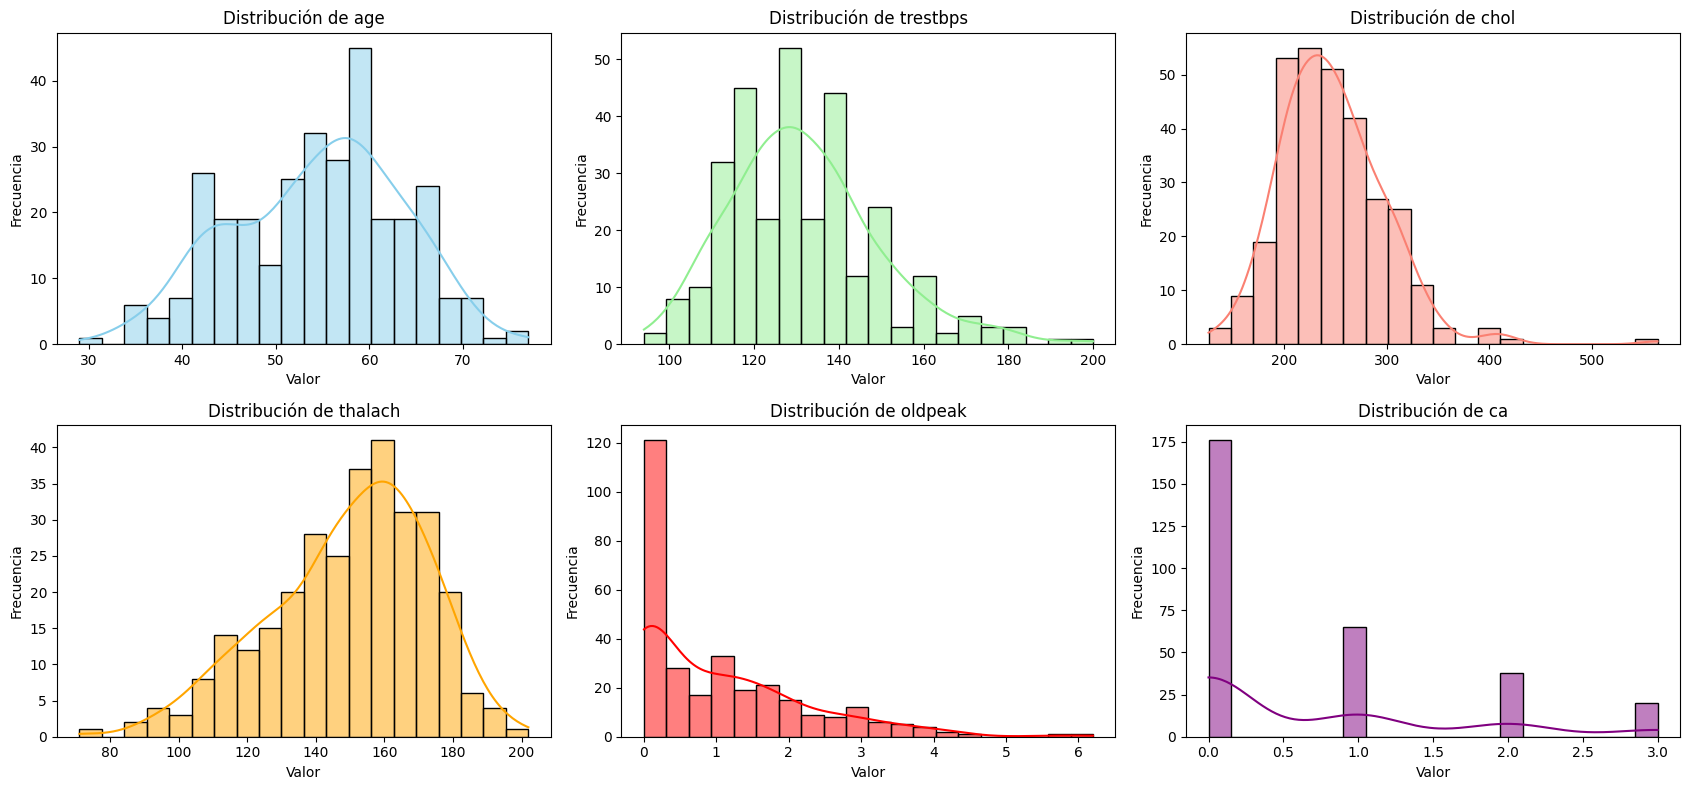

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
# Definición de las feautres que no son categóricas
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'red', 'purple']
for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    # Histograma con KDE
    sns.histplot(data=df, x=feature, kde=True, bins=20, ax=ax, color=colors[idx])
    ax.set_title(f'Distribución de {feature}')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribuciones_gráficas.png', dpi=300, bbox_inches='tight')
plt.show()

Se ha realizado una visualización con el fin de observar cómo se distribuye cada variable, descartando a las categóricas pues no aportan información de interés al graficarlas.

Al observar las gráficas se pueden confirmar las hipótesis de la estadística descriptiva.

En primer lugar, *age*  presenta dos picos, es decir dos subgrupos entre personas de mediana edad y otro entre personas de alrededor de 60 años. Además, se puede ver que las personas de casi 60 años son las más frecuentes.

Por otro lado, *trestbps* presenta una forma campana, aunque presenta valores outliers en la derecha, como se pudo comprobar en el apartado anterior.

En *chol* se puede comprobar que sigue una distribución normal (campana de gauss), pero presenta valores outliers alrededor de 400 y en 564.

En cuanto a *thalach* también sigue una distribución normal, y la mayoría se agrupa entre 150 y 175.

En *oldpeak* se pueden observar dos cosas, la primera es que presenta outliers alrededor de 6, mientras que la segunda es que está sesgada a la izquierda (presenta una cola larga en ese lado)

Por último, en *ca* los datos sólo pueden tener valores de 0, 1 , 2 o 3.

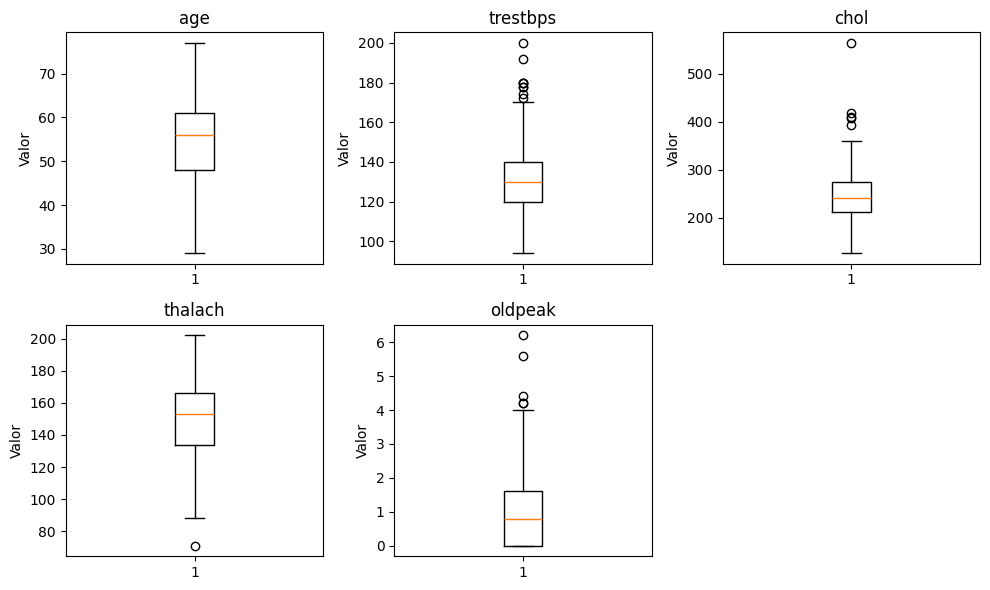

In [ ]:
# Plot de los outliers a modo resumen
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()
for idx, feature in enumerate(features):
    axes[idx].boxplot(df[feature])
    axes[idx].set_title(feature)
    axes[idx].set_ylabel('Valor')

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()


Finalmente, se ha realizado una visualización de los boxplots  de las variables con los outliers a modo resumen.

Cabe destacar que *thalach* presenta un valor atípico, pero no se ha mencionado anteriormente porque las demás variables contienen más de uno en comparación con ella.

## Manejo de Valores Faltantes

In [ ]:
# Eliminar filas con cualquier faltante
df_p = df.dropna()

Como se ha podido ver en el apartado 2, los valores faltantes suponen menos del 5% de las filas con datos faltantes. Aunque es más limpio y simple, hay que tener encuenta que esto implica una pérdida de información.

## Matriz de Correlación

               age  trestbps      chol   thalach   oldpeak        ca  \
age       1.000000  0.284946  0.208950 -0.393806  0.203805  0.362605   
trestbps  0.284946  1.000000  0.130120 -0.045351  0.189171  0.098773   
chol      0.208950  0.130120  1.000000 -0.003432  0.046564  0.119000   
thalach  -0.393806 -0.045351 -0.003432  1.000000 -0.343085 -0.264246   
oldpeak   0.203805  0.189171  0.046564 -0.343085  1.000000  0.295832   
ca        0.362605  0.098773  0.119000 -0.264246  0.295832  1.000000   
sex      -0.097542 -0.064456 -0.199915 -0.048663  0.102173  0.093185   
cp        0.104139 -0.036077  0.072319 -0.334422  0.202277  0.233214   
fbs       0.118530  0.175340  0.009841 -0.007854  0.005747  0.145478   
restecg   0.148868  0.146560  0.171043 -0.083389  0.114133  0.128343   
exang     0.091661  0.064762  0.061310 -0.378103  0.288223  0.145570   
slope     0.161770  0.117382 -0.004062 -0.385601  0.577537  0.110119   
thal      0.127389  0.133554  0.014214 -0.279631  0.341004  0.25

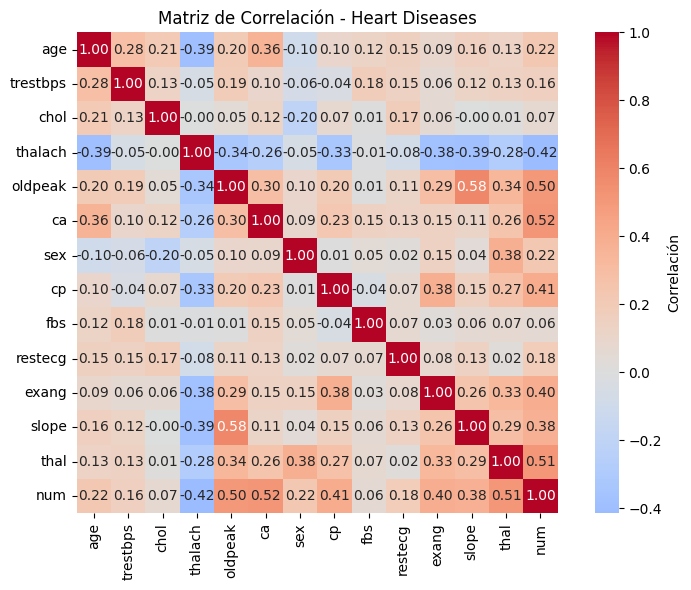

In [ ]:
# Matriz de correlación
features2 = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'num']
corr_matrix = df[features2].corr()
print(corr_matrix)

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación - Heart Diseases')
plt.tight_layout()
plt.savefig('correlacion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


Como se puede observar en la matriz de correlación, cada variable presenta consigo misma una correlación de 1. Además, se aprecia que es simétrica.

En cuanto a las correlaciones positivas fuertes, las variables *ca* (0.52), *thal* (0.51), *oldpeak* (0.50) y *cp* (0.40) muestran una relación fuerte positiva con el objetivo *num*, indicando que estas variables aumentan la probabilidad de una enfermedad cardíaca.

Cabe destacar también, que *thalach* contiene una relación negativa moderada con el resto de variables, pues una menor frecuencia cardíaca máxima suele estar relacionada con una mayor probabilidad de una enfermada cardíaca (-0.42)

## Imbalance y Representatividad

A continuación, se ha realizado un gráfico para observar la distribución de los diagnósticos de enfermadad cardíaca que compone el target.

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


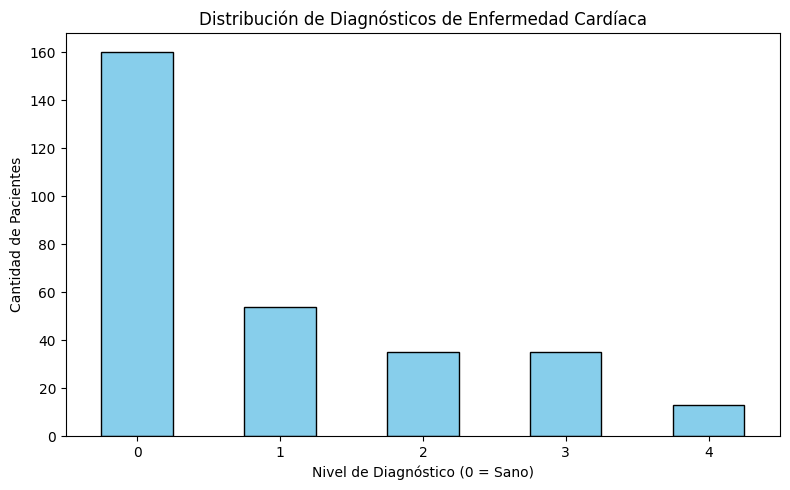

In [ ]:
# Conteo de clases
print(df['num'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
df_p['num'].value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')

ax.set_title('Distribución de Diagnósticos de Enfermedad Cardíaca')
ax.set_xlabel('Nivel de Diagnóstico (0 = Sano)')
ax.set_ylabel('Cantidad de Pacientes')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=300, bbox_inches='tight')
plt.show()

Como se puede observar, la mayoría de los pacientes se encuentran sanos (160), por lo que el dataset no está balanceado. Por lo tanto hay que tener en cuenta que la métrica Accuracy no será fiable y se le dará más prioridad a otras como F1-Score.

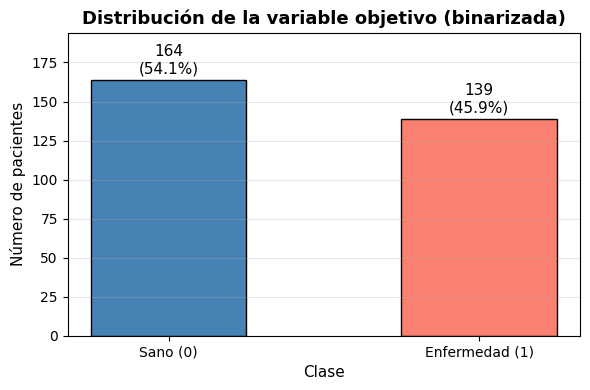

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

df_binary = df.copy()
df_binary['target'] = (df_binary['num'] > 0).astype(int)
counts = df_binary['target'].value_counts().sort_index()
labels = ['Sano (0)', 'Enfermedad (1)']
colors = ['steelblue', 'salmon']

bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{count}\n({count/counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de la variable objetivo (binarizada)', fontsize=13, fontweight='bold')
ax.set_xlabel('Clase', fontsize=11)
ax.set_ylabel('Número de pacientes', fontsize=11)
ax.set_ylim(0, max(counts.values) + 30)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribucion_target_binario.png', dpi=150)
plt.show()

Además, se ha realizado una clasifiación binaria entre lo que están sanos y los enfermos, y se puede observar cierto desbalance.

## PCA

Para finalizar se ha realizado una proyección PCA del dataset como se muestra a continuación.

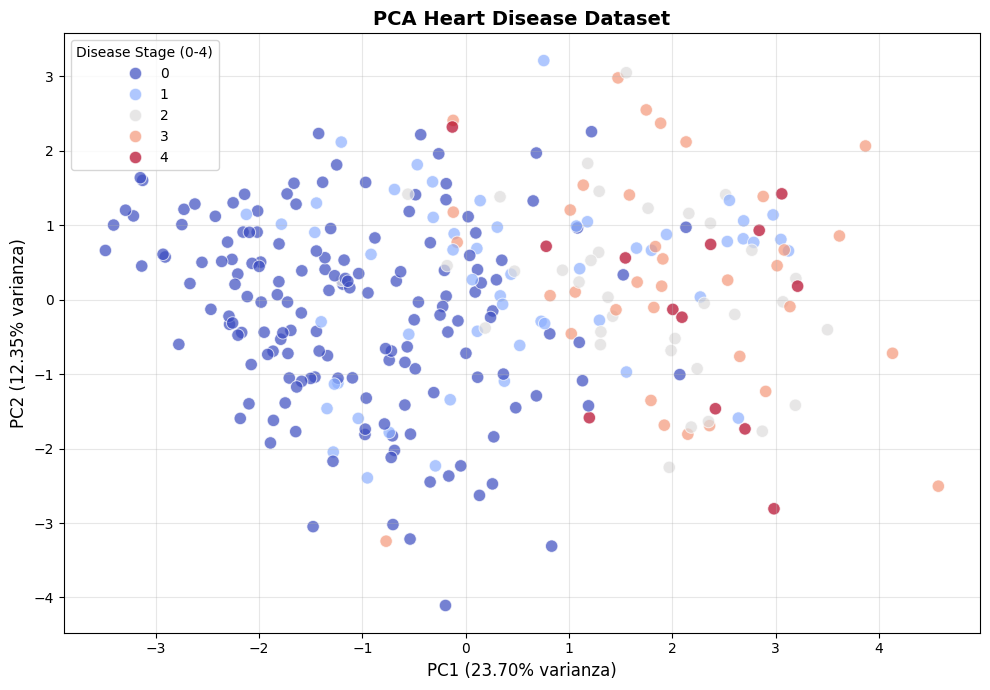

In [ ]:
features = df_p.drop(columns=['num'])

features = features.fillna(features.median())

x_scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

pca_df['num'] = df_p['num'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='num', data=pca_df, alpha=0.7, s=80, palette='coolwarm')

plt.title('PCA Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)', fontsize=12)

plt.legend(title='Disease Stage (0-4)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('PCA.png')
plt.show()


Como se puede observar, la mayoría de los pcaientes que están sanos, es decir los de las clase azul oscuro, se agrupan en la derecha, en los valores positivos de PC1, mientras que las demás etapas tienden a desplazarse hacia el lado izquierdo y están muy mezcladas entre sí, por lo que va a suponer una difcultad saber en qué etapa se encuentra exactamente un paciente.

## 4. Metodología

### 4.1 Preprocesamiento

La cadena de preprocesamiento incluye los siguientes pasos: binarización del target, división train/test con estratificación, imputación de valores ausentes, escalado de variables numéricas y codificación de variables categóricas.

Todas las transformaciones se encapsulan en un **Pipeline** de scikit-learn para evitar *data leakage*: el ajuste de los transformadores se realiza sobre el conjunto de entrenamiento y se aplica después al de test.

#### 4.1.1 Eliminación de filas con valores ausentes

El análisis exploratorio identificó 6 filas con valores nulos (4 en **ca** y 2 en **thal**), lo que representa menos del 2% del dataset. Se eliminan del **df** original en esta etapa, ya que su proporción es suficientemente pequeña para que la pérdida de información sea despreciable.

El **SimpleImputer** del pipeline se mantiene igualmente como red de seguridad ante posibles nulos en datos futuros.

In [ ]:
# Eliminar filas con valores nulos sobre el df original
# Solo afecta a 'ca' (4 nulos) y 'thal' (2 nulos) → 6 filas (<2%)
print(f"Filas antes de dropna: {len(df)}")
df = df.dropna()
print(f"Filas después de dropna: {len(df)}")
print(f"Filas eliminadas: {303 - len(df)}")

Filas antes de dropna: 303
Filas después de dropna: 297
Filas eliminadas: 6


#### 4.1.2 Binarización del target

La variable objetivo **num** toma valores de 0 a 4, donde 0 indica ausencia de enfermedad y cualquier valor > 0 indica algún grado de enfermedad cardíaca. Para abordar el problema como **clasificación binaria** se convierte a 0/1.

Esta decisión simplifica el problema y está alineada con el uso habitual de este dataset en la literatura.

In [ ]:
# Binarizar el target: 0 = sano, 1 = enfermedad cardíaca (cualquier grado)
df['target'] = (df['num'] > 0).astype(int)

print("Distribución del target:")
print(df['target'].value_counts())
print(f"\nProporción positivos: {df['target'].mean():.2%}")

Distribución del target:
target
0    160
1    137
Name: count, dtype: int64

Proporción positivos: 46.13%


#### 4.1.3 Definición de features y split train/test

Se separan las features del target y se realiza una división 80/20. Se usa **stratify=y** para que la proporción de casos positivos y negativos sea la misma en ambos conjuntos, lo cual es especialmente importante cuando hay cierto desbalance de clases.

In [ ]:
# Definir X e y (excluimos 'num' original y el nuevo 'target')
X = df.drop(columns=['num', 'target'])
y = df['target']

# Split 80/20 con estratificación para mantener proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Positivos en train: {y_train.mean():.2%} | Positivos en test: {y_test.mean():.2%}")

Train: 237 muestras | Test: 60 muestras
Positivos en train: 45.99% | Positivos en test: 46.67%


#### 4.1.4 Definición de features numéricas y categóricas

Aunque todas las variables están codificadas como números, algunas son **categóricas nominales u ordinales** (ya identificadas en el apartado 2). Se tratan de forma distinta:

- **Numéricas continuas**: age, trestbps, chol, thalach, oldpeak, ca → se imputan y escalan.
- **Categóricas**: sex, cp, fbs, restecg, exang, slope, thal → se imputan y codifican con OneHot.

In [ ]:
# Features numéricas continuas
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Features categóricas (codificadas como int en el dataset, pero son categorías)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

#### 4.1.5 Construcción del pipeline de transformación

**Transformador numérico:**
- SimpleImputer(strategy='median'): se usa la **mediana** en lugar de la media porque las variables chol, trestbps y oldpeak presentan outliers importantes (detectados en el apartado 3). La mediana es robusta frente a valores extremos.
- StandardScaler(): estandariza a media 0 y desviación 1, necesario para modelos sensibles a la escala (SVM, regresión logística, KNN).

**Transformador categórico:**
- SimpleImputer(strategy='most_frequent'): imputa los posibles nulos restantes con el valor más frecuente, apropiado para variables nominales.
- OneHotEncoder(drop='first', handle_unknown='ignore'): codifica como variables dummy eliminando la primera categoría para evitar multicolinealidad.

In [ ]:
# Pipeline para variables numéricas
# Usamos mediana porque chol, trestbps y oldpeak tienen outliers significativos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

#### 4.1.6 ColumnTransformer: unión de ambas ramas

**ColumnTransformer** aplica cada pipeline a su subconjunto de columnas y concatena los resultados horizontalmente. El parámetro **remainder='drop'** descarta cualquier columna no especificada explícitamente.

In [ ]:
# Unir ambas ramas en un único preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

#### 4.1.7 Verificación del preprocesador

Se ajusta el preprocesador **solo sobre el train** y se transforma tanto train como test. Se comprueba que las dimensiones son las esperadas.

In [ ]:
# Ajustar SOLO sobre train y transformar ambos conjuntos
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Número de features tras el preprocesamiento
# 6 numéricas + OneHot de las 7 categóricas (con drop='first')
print(f"Shape X_train preprocesado: {X_train_proc.shape}")
print(f"Shape X_test  preprocesado: {X_test_proc.shape}")

# Nombres de las features resultantes (útil para interpretar el modelo)
cat_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)
print(f"\nFeatures resultantes ({len(all_feature_names)}):")
print(all_feature_names)

Shape X_train preprocesado: (237, 18)
Shape X_test  preprocesado: (60, 18)

Features resultantes (18):
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0', 'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']


### 4.1.8 Balanceo de clases con SMOTETomek

Aunque el desbalance entre clases no es extremo (160 sanos vs 137 enfermos), en un contexto médico incluso una ligera asimetría puede sesgar el modelo hacia la clase mayoritaria, penalizando el Recall sobre la clase positiva (enfermos). Se aplica **SMOTETomek** sobre el conjunto de entrenamiento ya preprocesado, que combina dos técnicas: primero genera muestras sintéticas de la clase minoritaria mediante SMOTE (interpolación entre vecinos cercanos), y después elimina los **Tomek Links**, es decir, pares de muestras de clases distintas que son vecinos muy próximos y que confunden la frontera de decisión. Este enfoque es más robusto que SMOTE estándar porque no solo aumenta los datos sino que limpia las zonas de solapamiento entre clases. El test nunca se toca.

In [ ]:
# Hiperparámetros
K_NEIGHBORS = 5   # Vecinos para generar muestras sintéticas # Valores a probar: [3, 7, 10]
SEED        = 42

smote_tomek = SMOTETomek(
    smote=SMOTE(k_neighbors=K_NEIGHBORS, random_state=SEED),
    random_state=SEED
)
X_train_bal, y_train_bal = smote_tomek.fit_resample(X_train_proc, y_train)

print("Distribución ANTES de SMOTETomek:")
print(f"  Clase 0 (sano):    {(y_train == 0).sum()}")
print(f"  Clase 1 (enfermo): {(y_train == 1).sum()}")
print(f"  Total:             {len(y_train)}")

print("\nDistribución DESPUÉS de SMOTETomek:")
print(f"  Clase 0 (sano):    {(y_train_bal == 0).sum()}")
print(f"  Clase 1 (enfermo): {(y_train_bal == 1).sum()}")
print(f"  Total:             {len(y_train_bal)}")

Distribución ANTES de SMOTETomek:
  Clase 0 (sano):    128
  Clase 1 (enfermo): 109
  Total:             237

Distribución DESPUÉS de SMOTETomek:
  Clase 0 (sano):    117
  Clase 1 (enfermo): 117
  Total:             234


## 4.2 Modelo Baseline

Como punto de referencia para evaluar el impacto de las técnicas aplicadas a cada problemática, se entrena un modelo baseline sencillo e interpretable. Se elige la **Regresión Logística** por varias razones: es un modelo lineal estándar para clasificación binaria, es sensible a la escala (por eso el preprocesamiento con StandardScaler es crucial), tiene una complejidad baja que encaja bien con el tamaño reducido del dataset, y sus coeficientes permiten una interpretación directa. Servirá como referencia para comparar los resultados obtenidos con los modelos más complejos de las problemáticas posteriores.

La evaluación se realiza con **validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento, reportando AUC-ROC, F1-score, Accuracy y Recall. Se usa AUC-ROC como métrica principal porque el dataset tiene cierto desbalance de clases y esta métrica no depende del umbral de decisión. El F1-score complementa al AUC-ROC capturando el equilibrio entre precisión y recall.

In [ ]:
def train_baseline(X_train, y_train,
                   C=1.0,
                   max_iter=1000,
                   solver='lbfgs',
                   n_splits=5,
                   seed=42):

    model = LogisticRegression(C=C, max_iter=max_iter, solver=solver, random_state=seed)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    scoring = {
        'roc_auc'  : 'roc_auc',
        'f1'       : make_scorer(f1_score),
        'accuracy' : 'accuracy',
        'recall'   : make_scorer(recall_score)
    }

    cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)

    metrics = {
        'AUC-ROC'  : cv_results['test_roc_auc'],
        'F1-Score' : cv_results['test_f1'],
        'Accuracy' : cv_results['test_accuracy'],
        'Recall'   : cv_results['test_recall']
    }

    # Entrenar modelo final sobre todo el train
    model.fit(X_train, y_train)

    df_results = pd.DataFrame({k: [f"{v.mean():.4f} ± {v.std():.4f}"] for k, v in metrics.items()})
    df_results.index = ['Baseline (LogReg)']
    df_results.to_csv('tables/baseline_results.csv')
    df_results.head(n=15)

    return model, df_results

In [ ]:
baseline_model, df_baseline = train_baseline(X_train_proc, y_train, 1.0, 1000, 'lbfgs', 5)
df_baseline

,AUC-ROC,F1-Score,Accuracy,Recall
Baseline (LogReg),0.8906 ± 0.0721,0.7861 ± 0.0845,0.8140 ± 0.0746,0.7511 ± 0.1100


In [ ]:
# Entrenar el modelo final sobre todo el train para usarlo después en test
baseline_model.fit(X_train_proc, y_train)

LogisticRegression(max_iter=1000, random_state=42)

#### 4.2.1 Visualización Curva ROC

Para evaluar visualmente el rendimiento del modelo baseline se genera la curva ROC sobre el conjunto de test. Esta curva representa la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales de decisión, siendo el área bajo la curva (AUC-ROC) la métrica principal del trabajo.

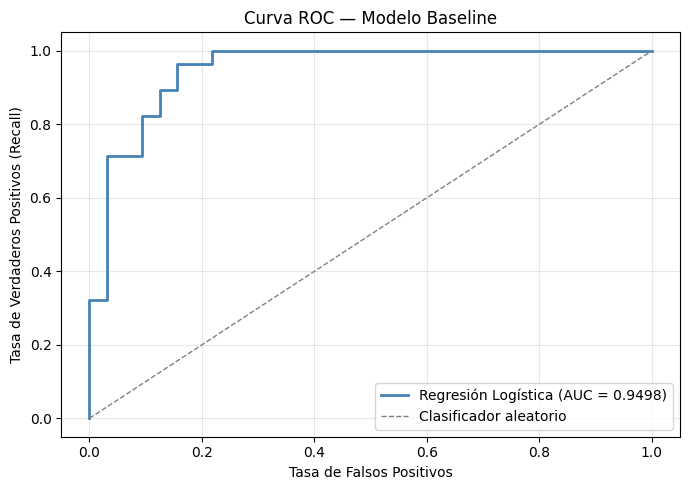

In [ ]:
# Probabilidades predichas por el baseline sobre el test
y_prob_baseline = baseline_model.predict_proba(X_test_proc)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_baseline)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Regresión Logística (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Modelo Baseline')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./images/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 Tratamiento de la Problemática 1: Privacidad (Aprendizaje Federado)

Para abordar la privacidad en datos médicos sensibles se simula un escenario de **aprendizaje federado** donde los datos están distribuidos entre varios clientes (hospitales) que nunca comparten sus datos directamente. Cada cliente entrena un modelo local sobre su partición y únicamente envía los parámetros del modelo al servidor central, que los agrega mediante el algoritmo **FedAvg** (Federated Averaging).

In [ ]:
# Hiperparámetros
N_CLIENTS    = 10       # Número de clientes (hospitales simulados)
N_ROUNDS     = 15       # Rondas de comunicación federada
N_EPOCHS     = 100      # Epochs locales por ronda por cliente
LEARNING_RATE = 0.05    # Tasa de aprendizaje del SGD local
LAMBDA        = 0.01    # Regularización L2
SEED          = 41
np.random.seed(SEED)

In [ ]:
# Dividir datos en clientes de forma estratificada

def split_data_for_clients(X, y, n_clients, seed=42):
    np.random.seed(seed)
    y = np.array(y)
    # Índices de cada clase
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    np.random.shuffle(idx_pos)
    np.random.shuffle(idx_neg)

    clients = []
    for i in range(n_clients):
        idx_p = idx_pos[i::n_clients]
        idx_n = idx_neg[i::n_clients]
        idx   = np.concatenate([idx_p, idx_n])
        np.random.shuffle(idx)
        clients.append((X[idx], y[idx]))
    return clients

In [ ]:
client_data = split_data_for_clients(X_train_proc, y_train, N_CLIENTS, SEED)

print(f"Clientes creados: {N_CLIENTS}")
for i, (X_c, y_c) in enumerate(client_data):
    print(f"  Cliente {i+1}: {len(y_c)} muestras | Positivos: {y_c.mean():.2%}")

Clientes creados: 10
  Cliente 1: 24 muestras | Positivos: 45.83%
  Cliente 2: 24 muestras | Positivos: 45.83%
  Cliente 3: 24 muestras | Positivos: 45.83%
  Cliente 4: 24 muestras | Positivos: 45.83%
  Cliente 5: 24 muestras | Positivos: 45.83%
  Cliente 6: 24 muestras | Positivos: 45.83%
  Cliente 7: 24 muestras | Positivos: 45.83%
  Cliente 8: 24 muestras | Positivos: 45.83%
  Cliente 9: 23 muestras | Positivos: 47.83%
  Cliente 10: 22 muestras | Positivos: 45.45%


In [ ]:
# Funciones de regresión logística manual con SGD

def sigmoid(z):
    return expit(z)

def local_train(X, y, params, lr, n_epochs, lam):
    """Entrena localmente con SGD sobre los parámetros recibidos del servidor."""
    w, b = params['w'].copy(), params['b'].copy()
    n = len(y)
    for _ in range(n_epochs):
        # Orden aleatorio
        idx = np.random.permutation(n)
        X_s, y_s = X[idx], y[idx]
        # Gradiente sobre todo el batch local
        y_pred = sigmoid(X_s @ w + b)
        error  = y_pred - y_s
        grad_w = (X_s.T @ error) / n + lam * w  # L2
        grad_b = error.mean()
        w -= lr * grad_w
        b -= lr * grad_b
    return {'w': w, 'b': b}

def fedavg(client_params_list, client_sizes):
    """Agrega parámetros ponderando por tamaño de cada cliente."""
    total  = sum(client_sizes)
    avg_w  = sum(p['w'] * n for p, n in zip(client_params_list, client_sizes)) / total
    avg_b  = sum(p['b'] * n for p, n in zip(client_params_list, client_sizes)) / total
    return {'w': avg_w, 'b': avg_b}

def predict(X, params, threshold=0.5):
    proba = sigmoid(X @ params['w'] + params['b'])
    return proba, (proba >= threshold).astype(int)

In [ ]:
# Inicializar parámetros globales

n_features = X_train_proc.shape[1]
global_params = {
    'w': np.zeros(n_features),
    'b': np.float64(0.0)
}

In [ ]:
# Bucle de entrenamiento federado

history = []

for ronda in range(1, N_ROUNDS + 1):

    client_params_list = []
    client_sizes       = []

    for X_c, y_c in client_data:
        local_params = local_train(X_c, y_c, global_params, LEARNING_RATE, N_EPOCHS, LAMBDA)
        client_params_list.append(local_params)
        client_sizes.append(len(y_c))

    # Agregación FedAvg
    global_params = fedavg(client_params_list, client_sizes)

    # Evaluar modelo global sobre test
    y_prob, y_pred = predict(X_test_proc, global_params)

    history.append({
        'Ronda'    : ronda,
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'F1-Score' : f1_score(y_test, y_pred),
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred)
    })

df_history = pd.DataFrame(history)
print("\nEvolución por ronda:")
print(df_history.to_string(index=False))

# Guardar resultados finales
df_fed_results = df_history[df_history['Ronda'] == N_ROUNDS].copy()
df_fed_results.index = ['Federado (FedAvg)']
df_fed_results = df_fed_results.drop(columns='Ronda')
df_fed_results.to_csv('tables/federated_results.csv')


Evolución por ronda:
 Ronda  AUC-ROC  F1-Score  Accuracy   Recall
     1 0.940848  0.851852  0.866667 0.821429
     2 0.945312  0.862745  0.883333 0.785714
     3 0.948661  0.846154  0.866667 0.785714
     4 0.946429  0.867925  0.883333 0.821429
     5 0.946429  0.851852  0.866667 0.821429
     6 0.945312  0.851852  0.866667 0.821429
     7 0.945312  0.851852  0.866667 0.821429
     8 0.946429  0.851852  0.866667 0.821429
     9 0.947545  0.851852  0.866667 0.821429
    10 0.945312  0.851852  0.866667 0.821429
    11 0.945312  0.851852  0.866667 0.821429
    12 0.947545  0.851852  0.866667 0.821429
    13 0.946429  0.851852  0.866667 0.821429
    14 0.946429  0.851852  0.866667 0.821429
    15 0.946429  0.851852  0.866667 0.821429


#### 4.3.1 Visualización del Aprendizaje Federado - Evolución por Rondas

Se representan las tres métricas principales a lo largo de las 15 rondas de comunicación federada. El objetivo es observar la velocidad de convergencia del modelo global y su estabilidad una vez alcanzado el rendimiento máximo.

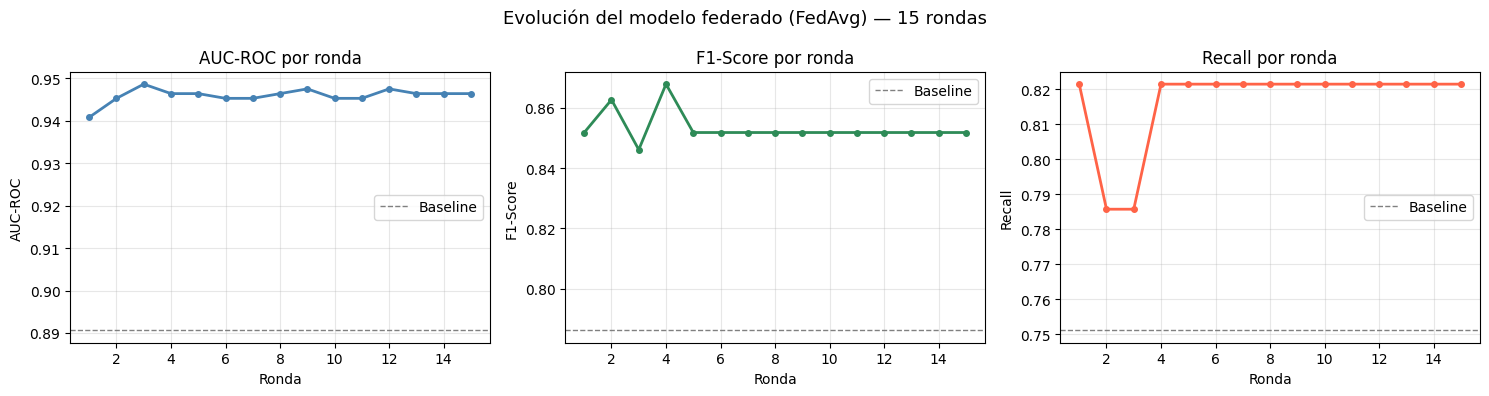

In [ ]:
# df_history ya está generado en la celda del bucle federado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = ['AUC-ROC', 'F1-Score', 'Recall']
colores  = ['steelblue', 'seagreen', 'tomato']

for ax, metrica, color in zip(axes, metricas, colores):
    ax.plot(df_history['Ronda'], df_history[metrica],
            color=color, lw=2, marker='o', markersize=4)
    # Línea del baseline como referencia
    baseline_vals = {'AUC-ROC': 0.8906, 'F1-Score': 0.7861, 'Recall': 0.7511}
    ax.axhline(y=baseline_vals[metrica], color='gray', lw=1,
               linestyle='--', label='Baseline')
    ax.set_title(f'{metrica} por ronda')
    ax.set_xlabel('Ronda')
    ax.set_ylabel(metrica)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Evolución del modelo federado (FedAvg) — 15 rondas', fontsize=13)
plt.tight_layout()
plt.savefig('images/federado_evolucion.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.4 Tratamiento de la Problemática 2: Escasez de datos (SMOTETomek + Random Forest)

Para abordar la escasez de datos y el desbalance de clases se combina el balanceo con **SMOTETomek** (aplicado en el 4.1.8) con un modelo **Random Forest**, que es un ensemble de árboles de decisión robusto ante overfitting en datasets pequeños. Se entrena sobre X_train_bal e y_train_bal (datos balanceados) y se evalúa sobre X_test_proc (test original sin tocar) mediante validación cruzada estratificada de 5 folds. Los resultados se comparan directamente con el baseline para cuantificar el impacto del balanceo y del modelo más potente.

In [ ]:
# Hiperparámetros Random Forest
N_ESTIMATORS = 500   # Número de árboles
MAX_DEPTH    = None  # Profundidad máxima
MIN_SAMPLES  = 2     # Mínimo muestras por hoja
SEED         = 42

def train_smote_model(X_train, y_train,
                      n_estimators=100,
                      max_depth=None,
                      min_samples_leaf=2,
                      n_splits=5,
                      seed=42):

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    scoring = {
        'roc_auc'  : 'roc_auc',
        'f1'       : make_scorer(f1_score),
        'accuracy' : 'accuracy',
        'recall'   : make_scorer(recall_score)
    }

    cv_results = cross_validate(model, X_train, y_train, cv=cv,
                                scoring=scoring, return_train_score=False)

    metrics = {
        'AUC-ROC'  : cv_results['test_roc_auc'],
        'F1-Score' : cv_results['test_f1'],
        'Accuracy' : cv_results['test_accuracy'],
        'Recall'   : cv_results['test_recall']
    }

    # Entrenar modelo final sobre todo el train balanceado
    model.fit(X_train, y_train)

    df_results = pd.DataFrame({k: [f"{v.mean():.4f} ± {v.std():.4f}"] for k, v in metrics.items()})
    df_results.index = ['SMOTETomek + RF']
    df_results.to_csv('tables/smote_results.csv')

    return model, df_results


rf_model, df_smote = train_smote_model(X_train_bal, y_train_bal,
                                        n_estimators=N_ESTIMATORS,
                                        max_depth=MAX_DEPTH,
                                        min_samples_leaf=MIN_SAMPLES,
                                        seed=SEED)
df_smote

,AUC-ROC,F1-Score,Accuracy,Recall
SMOTETomek + RF,0.9266 ± 0.0204,0.8299 ± 0.0318,0.8376 ± 0.0220,0.8022 ± 0.0669


#### 4.4.1 Visualización - SMOTETomek + Random Forest

Se generan dos visualizaciones para evaluar el modelo: la curva ROC para comparar directamente con el baseline, y la importancia de características del Random Forest para entender qué variables son más relevantes en la predicción.

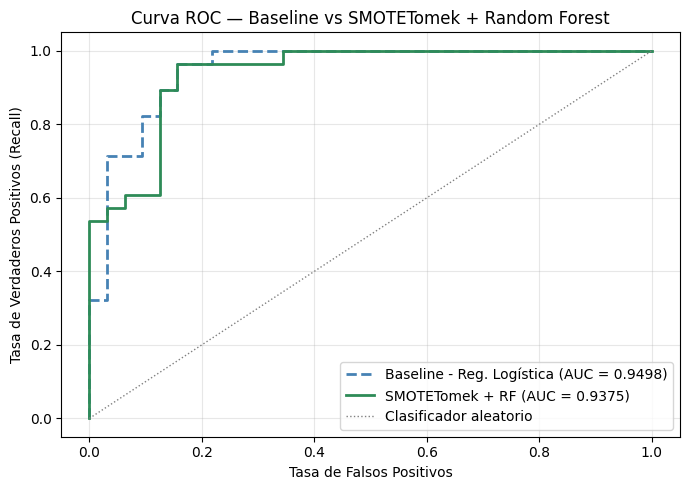

In [ ]:
# Curva ROC del Random Forest sobre el test
y_prob_rf = rf_model.predict_proba(X_test_proc)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# También recalculamos la del baseline para comparar en el mismo plot
y_prob_baseline = baseline_model.predict_proba(X_test_proc)[:, 1]
fpr_bl, tpr_bl, _ = roc_curve(y_test, y_prob_baseline)
roc_auc_bl = auc(fpr_bl, tpr_bl)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_bl, tpr_bl, color='steelblue', lw=2, linestyle='--',
        label=f'Baseline - Reg. Logística (AUC = {roc_auc_bl:.4f})')
ax.plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
        label=f'SMOTETomek + RF (AUC = {roc_auc_rf:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', label='Clasificador aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curva ROC — Baseline vs SMOTETomek + Random Forest')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/smote_rf_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

La curva ROC permite comparar directamente el Random Forest con el baseline sobre el mismo conjunto de test. La importancia de características revela qué variables tienen mayor peso en la decisión del modelo, lo cual es especialmente relevante en el contexto clínico para validar que el modelo se apoya en variables médicamente coherentes como thal, ca u oldpeak, que ya mostraron una correlación alta con el target en el análisis exploratorio.

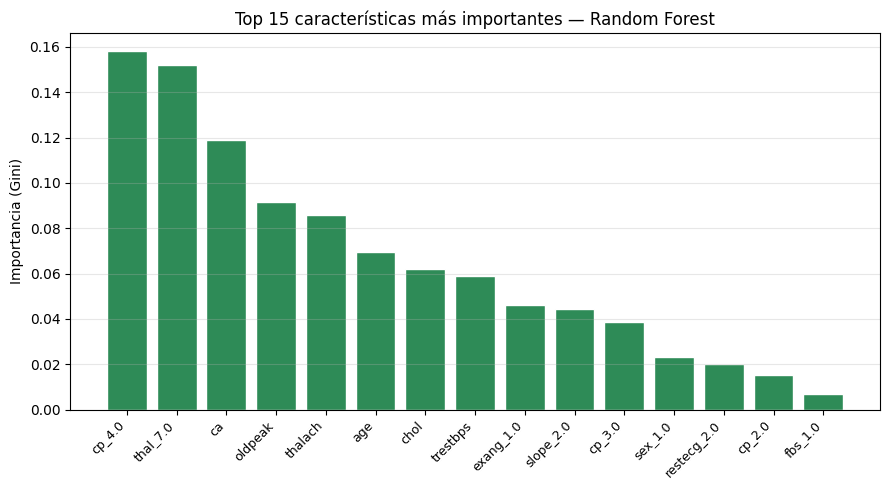

In [ ]:
# Importancia de características del Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Nombres de las features (generados en el preprocesamiento)
feature_names = np.array(all_feature_names)

# Mostramos las top 15 para no saturar el gráfico
top_n = 15
top_indices = indices[:top_n]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(top_n), importances[top_indices], color='seagreen', edgecolor='white')
ax.set_xticks(range(top_n))
ax.set_xticklabels(feature_names[top_indices], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Importancia (Gini)')
ax.set_title('Top 15 características más importantes — Random Forest')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/smote_rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.5 Combinación: Federado + SMOTETomek

Se combina el aprendizaje federado con el balanceo SMOTETomek para obtener la solución completa que aborda simultáneamente las dos problemáticas. Cada cliente aplica SMOTETomek sobre su partición local antes de entrenar, de forma que el balanceo se realiza de forma distribuida sin compartir datos. El servidor central agrega los parámetros con FedAvg como en el 4.3.

In [ ]:
# Hiperparámetros
N_CLIENTS     = 10    # Número de clientes
N_ROUNDS      = 15    # Rondas de comunicación
N_EPOCHS      = 100   # Epochs locales por ronda
LEARNING_RATE = 0.05  # Tasa de aprendizaje SGD
LAMBDA        = 0.01  # Regularización L2
K_NEIGHBORS   = 5     # Vecinos SMOTE por cliente
SEED          = 42
np.random.seed(SEED)


# Dividir datos balanceados en clientes
client_data_bal = split_data_for_clients(X_train_proc, y_train, N_CLIENTS, SEED)

print(f"Clientes creados: {N_CLIENTS}")
for i, (X_c, y_c) in enumerate(client_data_bal):
    print(f"  Cliente {i+1}: {len(y_c)} muestras | Positivos: {y_c.mean():.2%}")


# Aplicar SMOTETomek localmente en cada cliente
client_data_bal_smote = []
for i, (X_c, y_c) in enumerate(client_data_bal):
    # Solo aplicar SMOTE si hay suficientes muestras de cada clase
    if y_c.sum() >= K_NEIGHBORS + 1 and (len(y_c) - y_c.sum()) >= K_NEIGHBORS + 1:
        st = SMOTETomek(smote=SMOTE(k_neighbors=K_NEIGHBORS, random_state=SEED),
                        random_state=SEED)
        X_c_bal, y_c_bal = st.fit_resample(X_c, y_c)
    else:
        X_c_bal, y_c_bal = X_c, y_c
    client_data_bal_smote.append((X_c_bal, y_c_bal))
    print(f"  Cliente {i+1} tras SMOTETomek: {len(y_c_bal)} muestras | Positivos: {y_c_bal.mean():.2%}")


# Inicializar parámetros globales
n_features    = X_train_proc.shape[1]
global_params = {'w': np.zeros(n_features), 'b': np.float64(0.0)}


# Bucle federado con datos balanceados
history_combined = []

for ronda in range(1, N_ROUNDS + 1):

    client_params_list = []
    client_sizes       = []

    for X_c, y_c in client_data_bal_smote:
        local_params = local_train(X_c, y_c, global_params, LEARNING_RATE, N_EPOCHS, LAMBDA)
        client_params_list.append(local_params)
        client_sizes.append(len(y_c))

    global_params = fedavg(client_params_list, client_sizes)

    y_prob, y_pred = predict(X_test_proc, global_params)

    history_combined.append({
        'Ronda'    : ronda,
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
        'F1-Score' : f1_score(y_test, y_pred),
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred)
    })

df_history_combined = pd.DataFrame(history_combined)
print("\nEvolución por ronda (Federado + SMOTETomek):")
print(df_history_combined.to_string(index=False))

# Guardar resultados finales
df_combined_results = df_history_combined[df_history_combined['Ronda'] == N_ROUNDS].copy()
df_combined_results.index = ['Federado + SMOTETomek']
df_combined_results = df_combined_results.drop(columns='Ronda')
df_combined_results.to_csv('tables/combined_results.csv')

Clientes creados: 10
  Cliente 1: 24 muestras | Positivos: 45.83%
  Cliente 2: 24 muestras | Positivos: 45.83%
  Cliente 3: 24 muestras | Positivos: 45.83%
  Cliente 4: 24 muestras | Positivos: 45.83%
  Cliente 5: 24 muestras | Positivos: 45.83%
  Cliente 6: 24 muestras | Positivos: 45.83%
  Cliente 7: 24 muestras | Positivos: 45.83%
  Cliente 8: 24 muestras | Positivos: 45.83%
  Cliente 9: 23 muestras | Positivos: 47.83%
  Cliente 10: 22 muestras | Positivos: 45.45%
  Cliente 1 tras SMOTETomek: 22 muestras | Positivos: 50.00%
  Cliente 2 tras SMOTETomek: 22 muestras | Positivos: 50.00%
  Cliente 3 tras SMOTETomek: 26 muestras | Positivos: 50.00%
  Cliente 4 tras SMOTETomek: 24 muestras | Positivos: 50.00%
  Cliente 5 tras SMOTETomek: 20 muestras | Positivos: 50.00%
  Cliente 6 tras SMOTETomek: 26 muestras | Positivos: 50.00%
  Cliente 7 tras SMOTETomek: 26 muestras | Positivos: 50.00%
  Cliente 8 tras SMOTETomek: 24 muestras | Positivos: 50.00%
  Cliente 9 tras SMOTETomek: 22 muestras

### 4.5.1 Visualización — Federado + SMOTETomek (combinación)

Se genera el plot de evolución por rondas de la combinación de ambas soluciones, igual que en el 4.3, para poder comparar visualmente si añadir SMOTETomek al entrenamiento federado mejora o estabiliza las métricas.

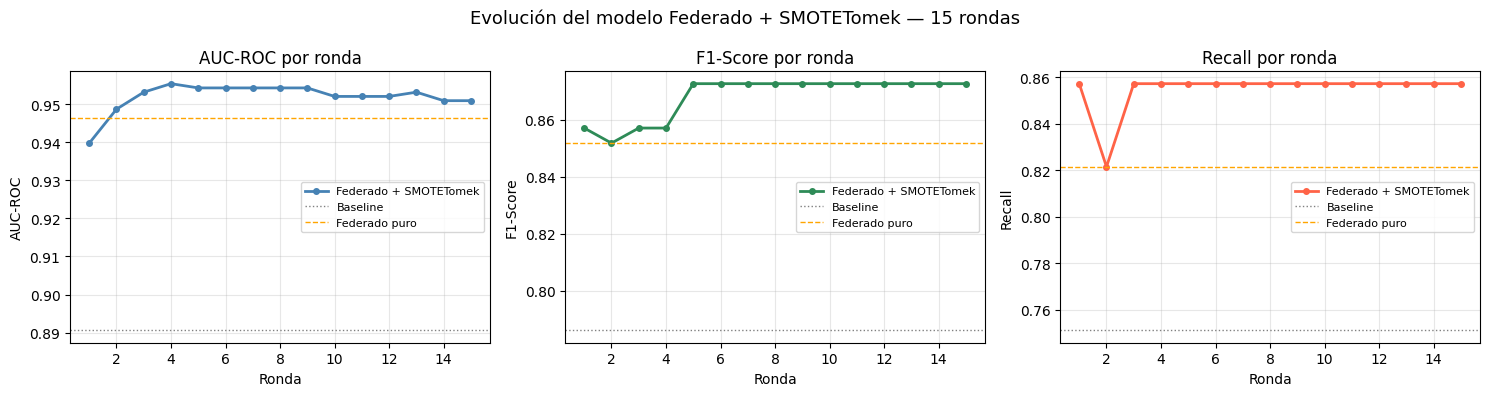

In [ ]:
# df_history_combined ya está generado en la celda del bucle federado + SMOTETomek
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metricas = ['AUC-ROC', 'F1-Score', 'Recall']
colores  = ['steelblue', 'seagreen', 'tomato']

# Valores de referencia: baseline y federado puro (ronda 15)
referencia_baseline  = {'AUC-ROC': 0.8906, 'F1-Score': 0.7861, 'Recall': 0.7511}
referencia_federado  = {'AUC-ROC': 0.9464, 'F1-Score': 0.8519, 'Recall': 0.8214}

for ax, metrica, color in zip(axes, metricas, colores):
    ax.plot(df_history_combined['Ronda'], df_history_combined[metrica],
            color=color, lw=2, marker='o', markersize=4, label='Federado + SMOTETomek')
    ax.axhline(y=referencia_baseline[metrica], color='gray', lw=1,
               linestyle=':', label='Baseline')
    ax.axhline(y=referencia_federado[metrica], color='orange', lw=1,
               linestyle='--', label='Federado puro')
    ax.set_title(f'{metrica} por ronda')
    ax.set_xlabel('Ronda')
    ax.set_ylabel(metrica)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Evolución del modelo Federado + SMOTETomek — 15 rondas', fontsize=13)
plt.tight_layout()
plt.savefig('images/combinado_evolucion.png', dpi=300, bbox_inches='tight')
plt.show()

Los tres gráficos permiten comparar directamente las tres configuraciones: baseline, federado puro y la combinación federado + SMOTETomek. La línea discontinua naranja marca el federado puro como segunda referencia, de forma que se puede ver claramente si añadir el balanceo local en cada cliente aporta mejora adicional o no sobre el modelo federado ya entrenado.

## 5. Experimentación

La metodología de evaluación sigue el siguiente protocolo:

1. **Selección de hiperparámetros**: Se utiliza `GridSearchCV` con **5-fold CV estratificado** sobre los datos de entrenamiento (con SMOTETomek) para identificar la mejor configuración de cada modelo. La partición de test **no se utiliza** en ningún momento durante este paso.
2. **Reentrenamiento final**: Una vez seleccionados los mejores hiperparámetros, se reentrena el modelo con **todos los datos de entrenamiento** (`X_train_bal`, `y_train_bal`).
3. **Evaluación en test**: Las métricas finales para la comparativa entre modelos se calculan sobre la **partición de test**, que permanece completamente aislada hasta este momento.

Se evalúan:

- **SVM** con kernels: lineal, RBF, polinomial y sigmoide
- **Random Forest**
- **Gradient Boosting**
- **AdaBoost**

Para cada modelo se reportan en test: AUC-ROC, F1, Recall, Precision y Accuracy.

In [ ]:
warnings.filterwarnings('ignore')
from sklearn.metrics import precision_score

scoring = {
    'roc_auc'   : 'roc_auc',
    'f1'        : make_scorer(f1_score),
    'recall'    : make_scorer(recall_score),
    'precision' : make_scorer(precision_score, zero_division=0),
    'accuracy'  : 'accuracy',
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# Grids de hiperparámetros

grids = {
    'SVM_linear': {
        'model': SVC(kernel='linear', probability=True, random_state=42),
        'param_grid': {'C': [0.01, 0.1, 1, 10, 100]},
    },
    'SVM_rbf': {
        'model': SVC(kernel='rbf', probability=True, random_state=42),
        'param_grid': {
            'C'    : [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
        },
    },
    'SVM_poly': {
        'model': SVC(kernel='poly', probability=True, random_state=42),
        'param_grid': {
            'C'     : [0.1, 1, 10],
            'degree': [2, 3, 4],
            'coef0' : [0, 1],
        },
    },
    'SVM_sigmoid': {
        'model': SVC(kernel='sigmoid', probability=True, random_state=42),
        'param_grid': {
            'C'     : [0.01, 0.1, 1, 10],
            'gamma' : ['scale', 'auto', 0.01],
            'coef0' : [0, 0.5, 1],
        },
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators'     : [100, 200, 300],
            'max_depth'        : [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 4],
            'max_features'     : ['sqrt', 'log2'],
        },
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'param_grid': {
            'n_estimators'     : [100, 200, 300],
            'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
            'max_depth'        : [3, 4, 5],
            'subsample'        : [0.8, 1.0],
            'min_samples_split': [2, 5],
        },
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            random_state=42
        ),
        'param_grid': {
            'n_estimators'         : [50, 100, 200, 300],
            'learning_rate'        : [0.01, 0.1, 0.5, 1.0],
            'estimator__max_depth' : [1, 2, 3],
        },
    },
}

for name, cfg in grids.items():
    total = 1
    for v in cfg['param_grid'].values():
        total *= len(v)
    print(f"  {name}: {total} combinaciones")


  SVM_linear: 5 combinaciones
  SVM_rbf: 16 combinaciones
  SVM_poly: 18 combinaciones
  SVM_sigmoid: 36 combinaciones
  RandomForest: 216 combinaciones
  GradientBoosting: 144 combinaciones
  AdaBoost: 48 combinaciones


In [ ]:
# GridSearch CV=5 sobre train

gs_results = {}

for name, cfg in grids.items():
    print(f"\n{'='*55}")
    print(f"  GridSearch: {name}")
    print(f"{'='*55}")
    t0 = time.time()

    # Selección de hiperparámetros con CV sobre train
    gs = GridSearchCV(
        estimator  = cfg['model'],
        param_grid = cfg['param_grid'],
        scoring    = 'roc_auc',
        cv         = cv5,
        refit      = True,   # reentrena con todos los datos de train
        n_jobs     = -1,
        verbose    = 0,
    )
    gs.fit(X_train_bal, y_train_bal)
    elapsed = time.time() - t0

    # Modelo final ya entrenado sobre todos los datos de train
    final_model = gs.best_estimator_

    # CV adicional solo para obtener desviaciones estándar
    cv_res = cross_validate(
        final_model, X_train_bal, y_train_bal,
        cv=cv5, scoring=scoring, return_train_score=False, n_jobs=-1
    )

    # Evaluación final en TEST
    y_prob_test = final_model.predict_proba(X_test_proc)[:, 1]
    y_pred_test = (y_prob_test >= 0.5).astype(int)

    test_metrics = {
        'AUC-ROC'   : roc_auc_score(y_test, y_prob_test),
        'F1'        : f1_score(y_test, y_pred_test),
        'Recall'    : recall_score(y_test, y_pred_test),
        'Precision' : precision_score(y_test, y_pred_test, zero_division=0),
        'Accuracy'  : accuracy_score(y_test, y_pred_test),
    }

    cv_stds = {
        'AUC-ROC'   : cv_res['test_roc_auc'].std(),
        'F1'        : cv_res['test_f1'].std(),
        'Recall'    : cv_res['test_recall'].std(),
        'Precision' : cv_res['test_precision'].std(),
        'Accuracy'  : cv_res['test_accuracy'].std(),
    }

    gs_results[name] = {
        'best_params'  : gs.best_params_,
        'best_score_cv': gs.best_score_,
        'cv_res'       : cv_res,
        'cv_stds'      : cv_stds,
        'test_metrics' : test_metrics,
        'elapsed_s'    : elapsed,
        'best_model'   : final_model,
    }

    print(f"  Mejor AUC-ROC (CV, selección HP): {gs.best_score_:.4f}")
    print(f"  Mejores params: {gs.best_params_}")
    print(f"  AUC-ROC en TEST: {test_metrics['AUC-ROC']:.4f}")
    print(f"  F1 en TEST:      {test_metrics['F1']:.4f}")
    print(f"  Tiempo total GS: {elapsed:.1f}s")


  GridSearch: SVM_linear
  Mejor AUC-ROC (CV, selección HP): 0.9120
  Mejores params: {'C': 0.01}
  AUC-ROC en TEST: 0.9587
  F1 en TEST:      0.8727
  Tiempo total GS: 8.0s

  GridSearch: SVM_rbf
  Mejor AUC-ROC (CV, selección HP): 0.9126
  Mejores params: {'C': 1, 'gamma': 0.01}
  AUC-ROC en TEST: 0.9609
  F1 en TEST:      0.8727
  Tiempo total GS: 2.6s

  GridSearch: SVM_poly
  Mejor AUC-ROC (CV, selección HP): 0.9282
  Mejores params: {'C': 1, 'coef0': 0, 'degree': 3}
  AUC-ROC en TEST: 0.9386
  F1 en TEST:      0.8519
  Tiempo total GS: 2.1s

  GridSearch: SVM_sigmoid
  Mejor AUC-ROC (CV, selección HP): 0.9134
  Mejores params: {'C': 0.1, 'coef0': 0, 'gamma': 'scale'}
  AUC-ROC en TEST: 0.9576
  F1 en TEST:      0.8727
  Tiempo total GS: 3.7s

  GridSearch: RandomForest
  Mejor AUC-ROC (CV, selección HP): 0.9364
  Mejores params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  AUC-ROC en TEST: 0.9269
  F1 en TEST: 

In [ ]:
# Tabla de métricas en TEST con desviación estándar del CV

metric_keys = {
    'AUC-ROC'   : 'test_roc_auc',
    'F1'        : 'test_f1',
    'Recall'    : 'test_recall',
    'Precision' : 'test_precision',
    'Accuracy'  : 'test_accuracy',
}

rows = []
for name, res in gs_results.items():
    row = {
        'Modelo'     : name,
        'Tiempo(s)'  : f"{res['elapsed_s']:.1f}",
        'AUC-ROC CV' : f"{res['best_score_cv']:.4f}",
    }
    for label in ['AUC-ROC', 'F1', 'Recall', 'Precision', 'Accuracy']:
        row[label]         = f"{res['test_metrics'][label]:.4f}"
        row[f'±{label}']   = f"{res['cv_stds'][label]:.4f}"
    rows.append(row)

df_gs = pd.DataFrame(rows).set_index('Modelo')
cols_ordered = ['Tiempo(s)', 'AUC-ROC CV']
for label in ['AUC-ROC', 'F1', 'Recall', 'Precision', 'Accuracy']:
    cols_ordered += [label, f'±{label}']
df_gs = df_gs[cols_ordered]

print("\nTabla de métricas en TEST (± std del CV, SMOTETomek):")
print(df_gs.to_string())
df_gs.to_csv('tables/gridsearch_results_test.csv')



Tabla de métricas en TEST (± std del CV, SMOTETomek):
                 Tiempo(s) AUC-ROC CV AUC-ROC ±AUC-ROC      F1     ±F1  Recall ±Recall Precision ±Precision Accuracy ±Accuracy
Modelo                                                                                                                        
SVM_linear             8.0     0.9120  0.9587   0.0252  0.8727  0.0669  0.8571  0.1098    0.8889     0.0262   0.8833    0.0397
SVM_rbf                2.6     0.9126  0.9609   0.0166  0.8727  0.0176  0.8571  0.0477    0.8889     0.0297   0.8833    0.0083
SVM_poly               2.1     0.9282  0.9386   0.0260  0.8519  0.0466  0.8214  0.0877    0.8846     0.0475   0.8667    0.0252
SVM_sigmoid            3.7     0.9134  0.9576   0.0275  0.8727  0.0436  0.8571  0.0843    0.8889     0.0271   0.8833    0.0254
RandomForest         478.2     0.9364  0.9269   0.0236  0.7692  0.0303  0.7143  0.0659    0.8333     0.0282   0.8000    0.0222
GradientBoosting     252.6     0.9140  0.9196   0.0209  

### 5.1 Tabla comparativa Baseline vs modelos propuestos (métricas en TEST)

Siguiendo el protocolo indicado, la comparativa final entre modelos se realiza sobre la **partición de test**. Para el baseline se reentrena también sobre todos los datos de train antes de evaluar.

In [ ]:
baseline_model.fit(X_train_proc, y_train)

# Métricas en TEST del baseline
y_prob_base_test = baseline_model.predict_proba(X_test_proc)[:, 1]
y_pred_base_test = (y_prob_base_test >= 0.5).astype(int)

baseline_test_metrics = {
    'AUC-ROC'   : roc_auc_score(y_test, y_prob_base_test),
    'F1'        : f1_score(y_test, y_pred_base_test),
    'Recall'    : recall_score(y_test, y_pred_base_test),
    'Precision' : precision_score(y_test, y_pred_base_test, zero_division=0),
    'Accuracy'  : accuracy_score(y_test, y_pred_base_test),
}

# CV para desviaciones estándar
baseline_cv = cross_validate(
    baseline_model, X_train_proc, y_train,
    cv=cv5, scoring=scoring, return_train_score=False, n_jobs=-1
)

baseline_row = {'Modelo': 'Baseline (LogReg)', 'Tiempo(s)': '—'}
for label, key in metric_keys.items():
    vals = baseline_cv[key]
    baseline_row[label]       = f"{vals.mean():.4f}"
    baseline_row[f'±{label}'] = f"{vals.std():.4f}"

df_compare = pd.concat([
    pd.DataFrame([baseline_row]).set_index('Modelo'),
    df_gs,
])
print("\nComparativa Baseline vs Modelos Propuestos (CV=5)")
print(df_compare.to_string())
df_compare.to_csv('tables/comparativa_baseline_propuestos.csv')


Comparativa Baseline vs Modelos Propuestos (CV=5)
                  Tiempo(s) AUC-ROC ±AUC-ROC      F1     ±F1  Recall ±Recall Precision ±Precision Accuracy ±Accuracy AUC-ROC CV
Modelo                                                                                                                         
Baseline (LogReg)         —  0.8906   0.0721  0.7861  0.0845  0.7511  0.1100    0.8349     0.0929   0.8140    0.0746        NaN
SVM_linear              8.0  0.9587   0.0252  0.8727  0.0669  0.8571  0.1098    0.8889     0.0262   0.8833    0.0397     0.9120
SVM_rbf                 2.6  0.9609   0.0166  0.8727  0.0176  0.8571  0.0477    0.8889     0.0297   0.8833    0.0083     0.9126
SVM_poly                2.1  0.9386   0.0260  0.8519  0.0466  0.8214  0.0877    0.8846     0.0475   0.8667    0.0252     0.9282
SVM_sigmoid             3.7  0.9576   0.0275  0.8727  0.0436  0.8571  0.0843    0.8889     0.0271   0.8833    0.0254     0.9134
RandomForest          478.2  0.9269   0.0236  0.7692 

### 5.2 Visualizaciones comparativas (métricas en TEST)

Las visualizaciones siguientes reflejan el rendimiento de cada modelo sobre la partición de test, que es la referencia para la comparativa final según el protocolo del profesor.

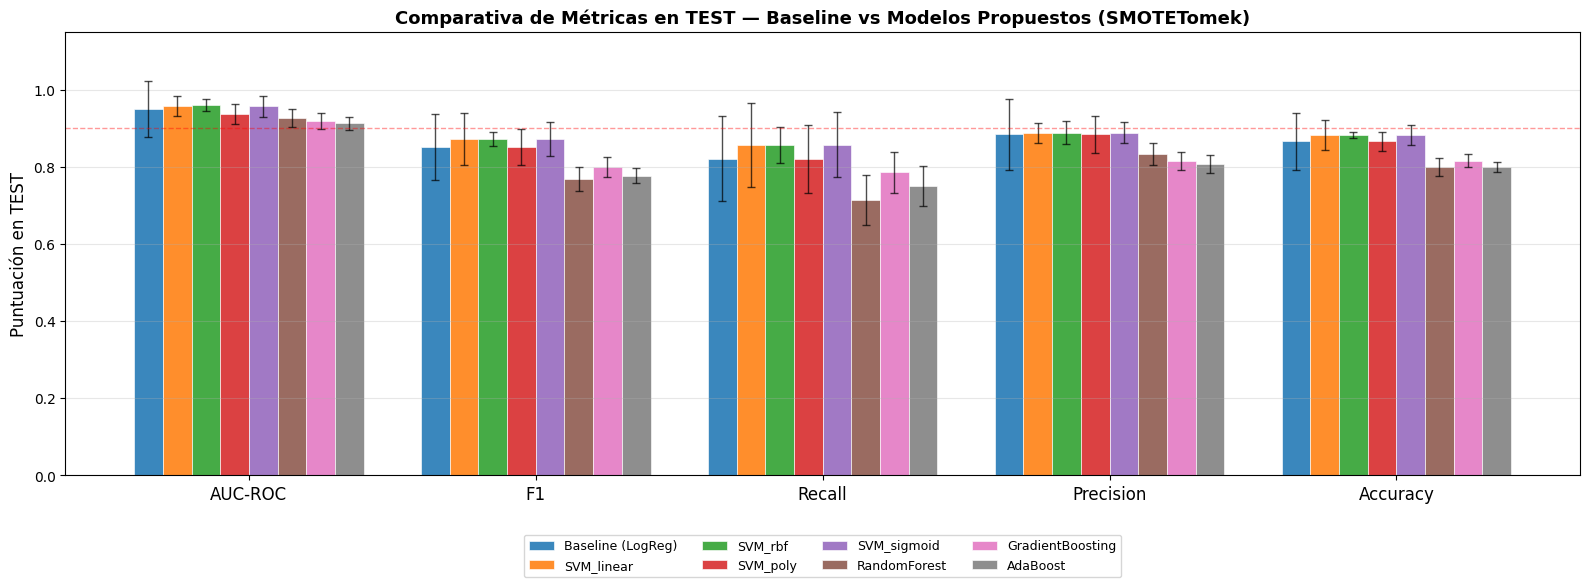

In [ ]:
metric_labels = ['AUC-ROC', 'F1', 'Recall', 'Precision', 'Accuracy']
model_names   = list(gs_results.keys())
all_names     = ['Baseline (LogReg)'] + model_names

# Valores de TEST
test_vals = {}
test_vals['Baseline (LogReg)'] = {lbl: baseline_test_metrics[lbl] for lbl in metric_labels}
for name, res in gs_results.items():
    test_vals[name] = {lbl: res['test_metrics'][lbl] for lbl in metric_labels}

# Desviaciones del CV
stds = {}
stds['Baseline (LogReg)'] = {lbl: baseline_cv[key].std() for lbl, key in metric_keys.items()}
for name, res in gs_results.items():
    stds[name] = {lbl: res['cv_stds'][lbl] for lbl in metric_labels}

palette = plt.cm.tab10.colors
colors  = {n: palette[i % 10] for i, n in enumerate(all_names)}

x     = np.arange(len(metric_labels))
width = 0.10
n_mod = len(all_names)
offs  = np.linspace(-(n_mod-1)/2*width, (n_mod-1)/2*width, n_mod)

fig, ax = plt.subplots(figsize=(16, 6))
for i, name in enumerate(all_names):
    vals = [test_vals[name][m] for m in metric_labels]
    errs = [stds[name][m]      for m in metric_labels]
    ax.bar(x + offs[i], vals, width=width, label=name,
           color=colors[name], edgecolor='white', linewidth=0.5, alpha=0.88,
           yerr=errs, capsize=3, error_kw={'linewidth': 1, 'alpha': 0.7})

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylabel('Puntuación en TEST', fontsize=12)
ax.set_title('Comparativa de Métricas en TEST — Baseline vs Modelos Propuestos (SMOTETomek)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, lw=1)

plt.tight_layout()
plt.savefig('images/comparativa_metricas_barras_test.png', dpi=300, bbox_inches='tight')
plt.show()

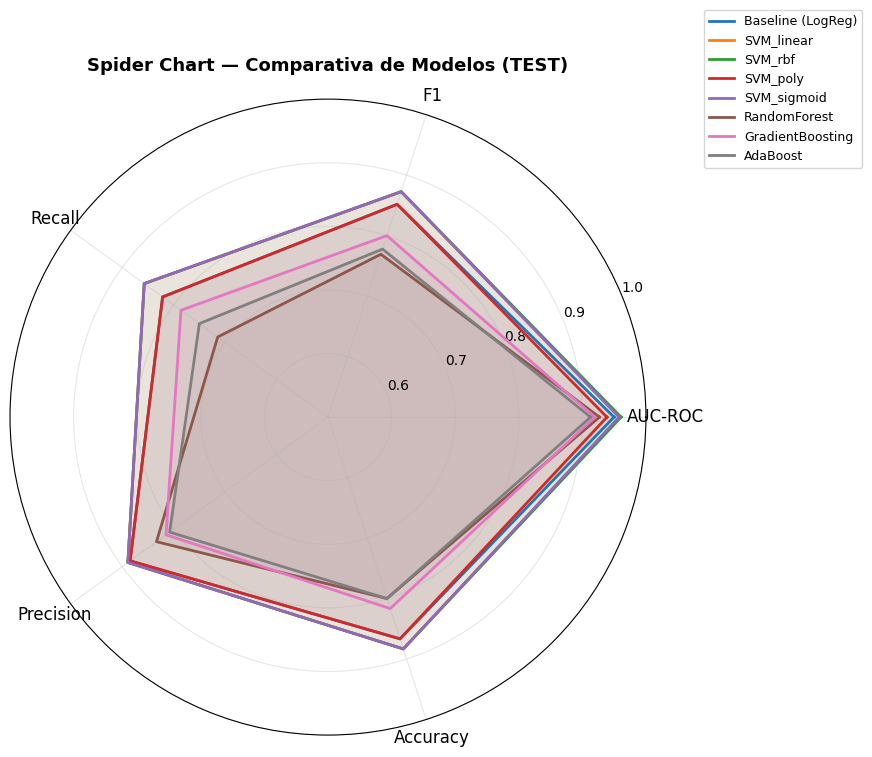

In [ ]:
cats   = ['AUC-ROC', 'F1', 'Recall', 'Precision', 'Accuracy']
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, name in enumerate(all_names):
    vals  = [test_vals[name][m] for m in cats]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=name, color=colors[name])
    ax.fill(angles, vals, alpha=0.07, color=colors[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_title('Spider Chart — Comparativa de Modelos (TEST)', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/spider_chart_modelos_test.png', dpi=300, bbox_inches='tight')
plt.show()

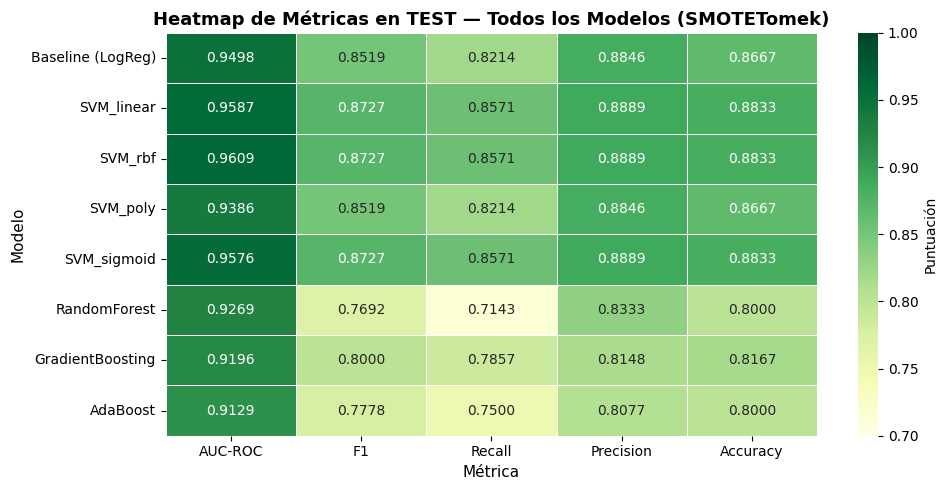

In [ ]:
heatmap_data = pd.DataFrame({
    name: {lbl: test_vals[name][lbl] for lbl in metric_labels}
    for name in all_names
}).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.7, vmax=1.0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Puntuación'})
ax.set_title('Heatmap de Métricas en TEST — Todos los Modelos (SMOTETomek)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Métrica', fontsize=11)
ax.set_ylabel('Modelo', fontsize=11)
plt.tight_layout()
plt.savefig('images/heatmap_metricas_test.png', dpi=300, bbox_inches='tight')
plt.show()

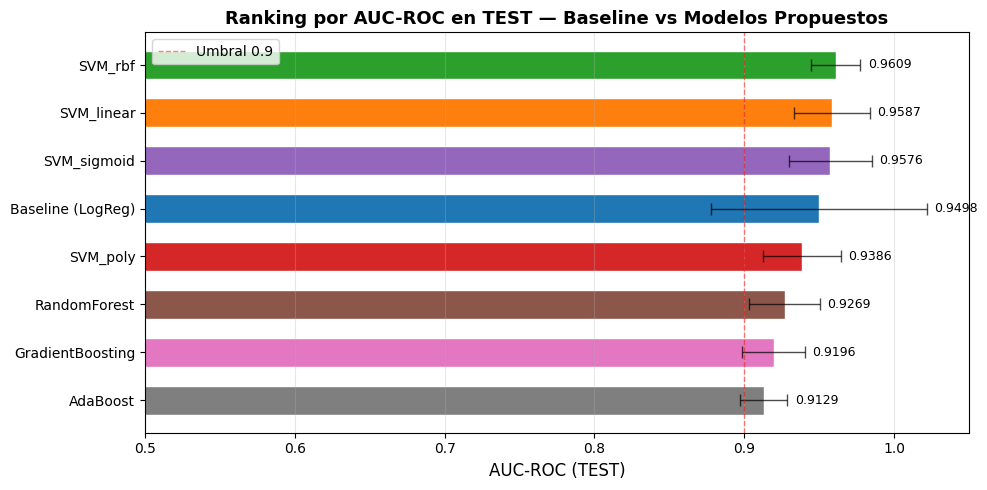

In [ ]:
auc_sorted = sorted(all_names, key=lambda n: test_vals[n]['AUC-ROC'], reverse=True)
vals_s = [test_vals[n]['AUC-ROC'] for n in auc_sorted]
errs_s = [stds[n]['AUC-ROC']      for n in auc_sorted]
cols_s = [colors[n]               for n in auc_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(auc_sorted[::-1], vals_s[::-1],
               xerr=errs_s[::-1], capsize=4,
               color=cols_s[::-1], edgecolor='white', height=0.6,
               error_kw={'linewidth': 1, 'alpha': 0.7})
ax.set_xlabel('AUC-ROC (TEST)', fontsize=12)
ax.set_title('Ranking por AUC-ROC en TEST — Baseline vs Modelos Propuestos',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 1.05)
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.5, lw=1, label='Umbral 0.9')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

for bar, val, err in zip(bars, vals_s[::-1], errs_s[::-1]):
    ax.text(val + err + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/ranking_auc_roc_test.png', dpi=300, bbox_inches='tight')
plt.show()

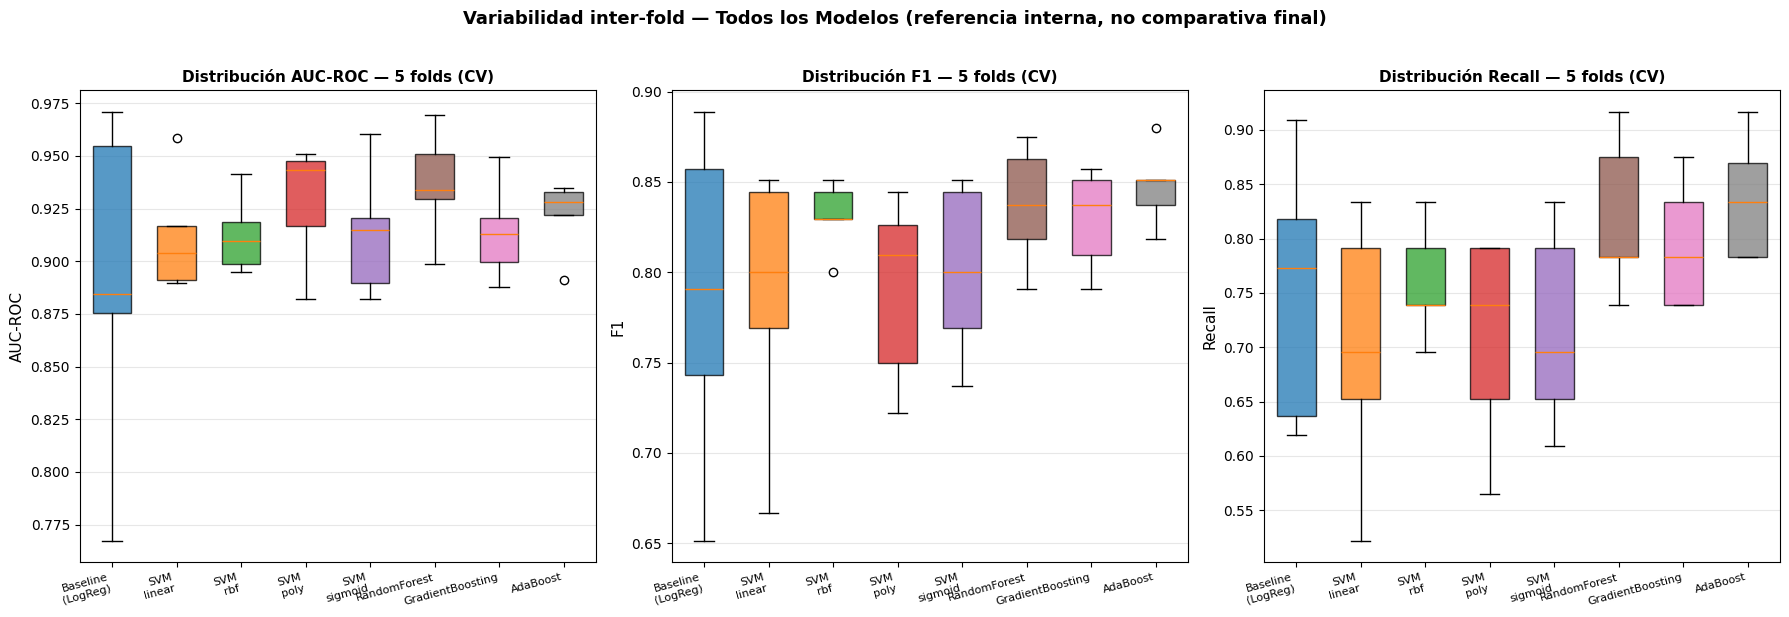

In [ ]:
# Boxplots CV
means = {}
means['Baseline (LogReg)'] = {lbl: baseline_cv[key].mean() for lbl, key in metric_keys.items()}
for name, res in gs_results.items():
    means[name] = {lbl: res['cv_res'][key].mean() for lbl, key in metric_keys.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metric_box = [('AUC-ROC', 'test_roc_auc'), ('F1', 'test_f1'), ('Recall', 'test_recall')]

for ax, (lbl, key) in zip(axes, metric_box):
    data_box   = [baseline_cv[key]] + [gs_results[n]['cv_res'][key] for n in model_names]
    labels_box = ['Baseline\n(LogReg)'] + [n.replace('_', '\n') for n in model_names]

    bplots = ax.boxplot(data_box, patch_artist=True, notch=False, widths=0.6)
    for patch, name in zip(bplots['boxes'], ['Baseline (LogReg)'] + model_names):
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.75)

    ax.set_xticklabels(labels_box, fontsize=8, rotation=15, ha='right')
    ax.set_ylabel(lbl, fontsize=11)
    ax.set_title(f'Distribución {lbl} — 5 folds (CV)', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Variabilidad inter-fold — Todos los Modelos (referencia interna, no comparativa final)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/boxplots_cv_folds.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("\nMejores Hiperparámetros por Modelo (seleccionados via 5-fold CV sobre train)\n")
rows_hp = []
for name, res in gs_results.items():
    rows_hp.append({
        'Modelo'             : name,
        'Mejor AUC-ROC (CV)' : f"{res['best_score_cv']:.4f}",
        'AUC-ROC (TEST)'     : f"{res['test_metrics']['AUC-ROC']:.4f}",
        'Mejores Params'     : str(res['best_params']),
    })
df_hp = pd.DataFrame(rows_hp).set_index('Modelo')
print(df_hp.to_string())
df_hp.to_csv('tables/best_hyperparams.csv')


Mejores Hiperparámetros por Modelo (seleccionados via 5-fold CV sobre train)

                 Mejor AUC-ROC (CV) AUC-ROC (TEST)                                                                                                   Mejores Params
Modelo                                                                                                                                                             
SVM_linear                   0.9120         0.9587                                                                                                      {'C': 0.01}
SVM_rbf                      0.9126         0.9609                                                                                          {'C': 1, 'gamma': 0.01}
SVM_poly                     0.9282         0.9386                                                                                {'C': 1, 'coef0': 0, 'degree': 3}
SVM_sigmoid                  0.9134         0.9576                                                   

## Tratamiento de la problemática 3: Explicabilidad con SHAP

Se selecciona el mejor modelo según **AUC-ROC en test** y se aplica SHAP completo: summary plot, bar plot, dependence plots, waterfall plots y force plot.


In [ ]:
best_gs_name  = max(gs_results, key=lambda k: gs_results[k]['test_metrics']['AUC-ROC'])
best_gs_model = gs_results[best_gs_name]['best_model']

print(f"Mejor modelo (AUC-ROC en TEST): {best_gs_name}")
print(f"AUC-ROC en TEST: {gs_results[best_gs_name]['test_metrics']['AUC-ROC']:.4f}")
print(f"Params: {gs_results[best_gs_name]['best_params']}")
print("\n(El modelo ya está entrenado sobre todos los datos de train via refit=True)")

Mejor modelo (AUC-ROC en TEST): SVM_rbf
AUC-ROC en TEST: 0.9609
Params: {'C': 1, 'gamma': 0.01}

(El modelo ya está entrenado sobre todos los datos de train via refit=True)


In [ ]:
# SHAP TreeExplainer sobre RF

feature_names_shap = list(preprocessor.get_feature_names_out())

# Para SHAP usamos el mejor modelo RF del GS
rf_shap = gs_results['RandomForest']['best_model']
rf_shap.fit(X_train_bal, y_train_bal)

explainer_gs = shap.TreeExplainer(rf_shap)
sv = explainer_gs.shap_values(X_test_proc)

# Clase positiva
if isinstance(sv, list):
    shap_vals_gs = sv[1]
elif hasattr(sv, 'ndim') and sv.ndim == 3:
    shap_vals_gs = sv[:, :, 1]
else:
    shap_vals_gs = sv

print(f"SHAP values shape: {shap_vals_gs.shape}")


SHAP values shape: (60, 18)


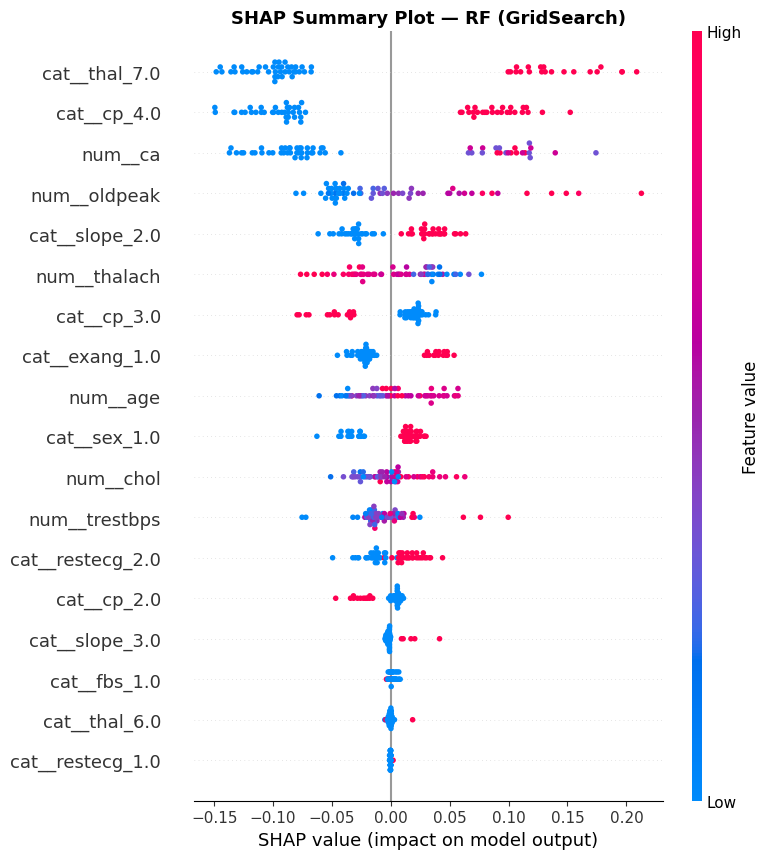

In [ ]:
# Summary Plot

shap.summary_plot(shap_vals_gs, X_test_proc,
                  feature_names=feature_names_shap, show=False)
plt.title('SHAP Summary Plot — RF (GridSearch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_gs_summary.png', dpi=300, bbox_inches='tight')
plt.show()


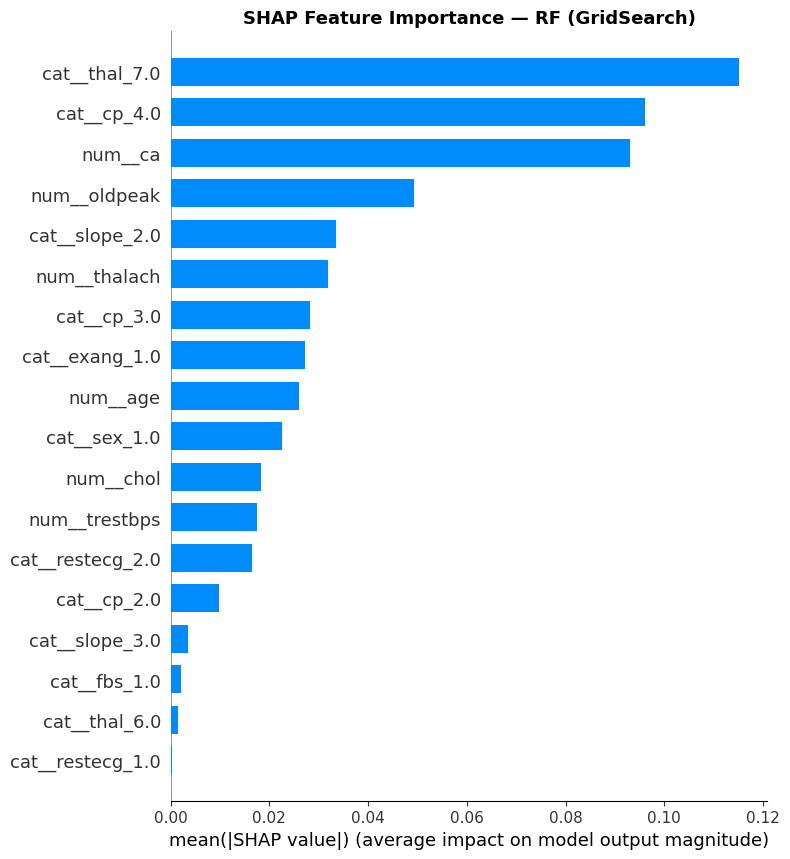

In [ ]:
# Bar Plot - importancia media global

shap.summary_plot(shap_vals_gs, X_test_proc,
                  feature_names=feature_names_shap,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — RF (GridSearch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_gs_bar.png', dpi=300, bbox_inches='tight')
plt.show()


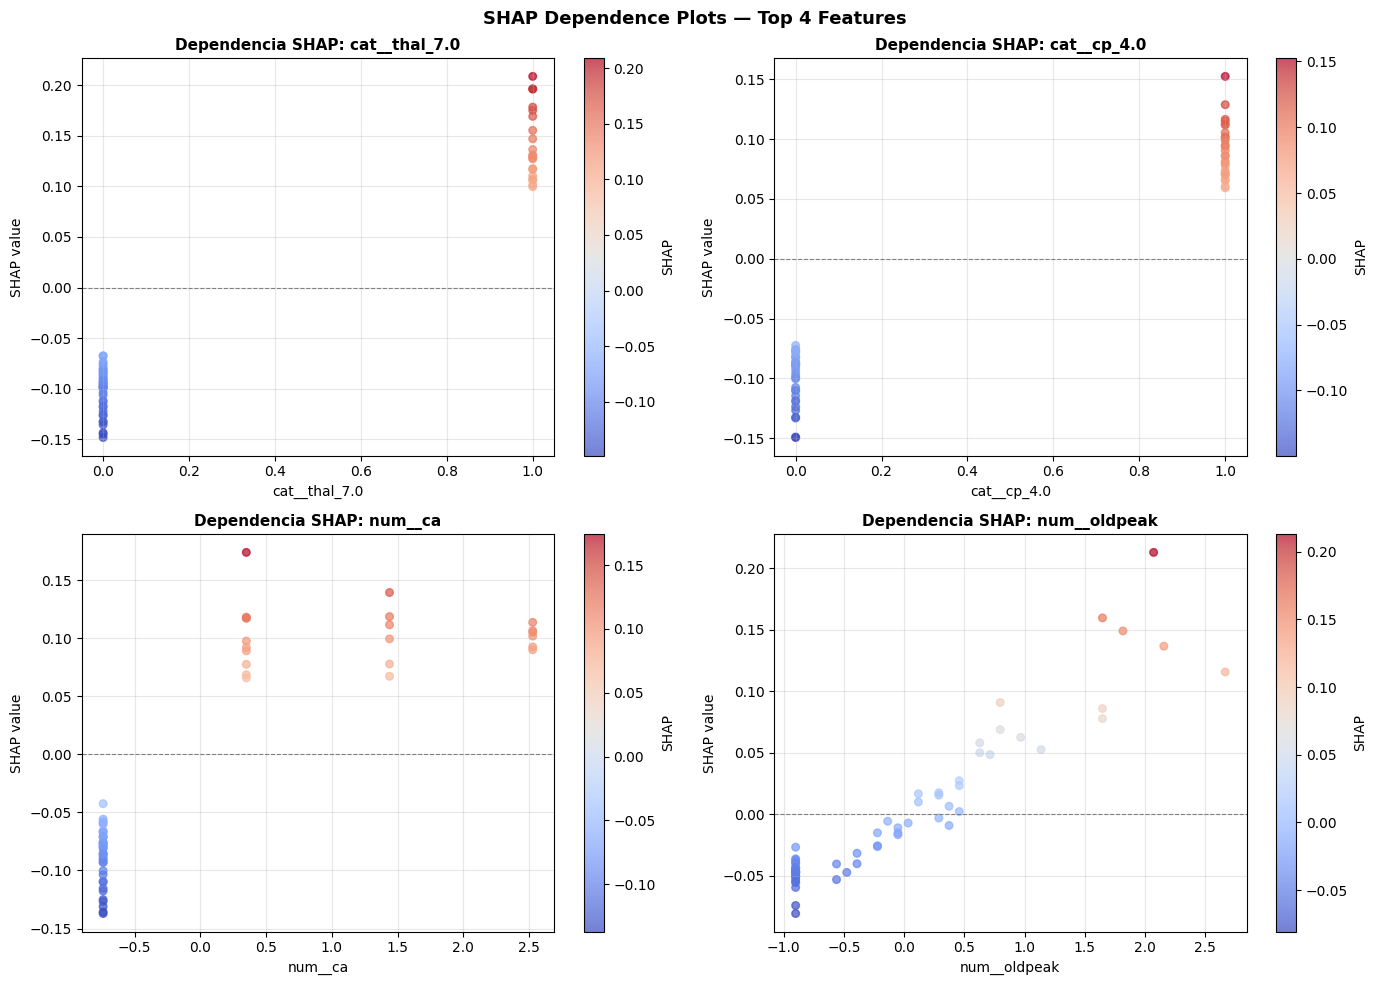

In [ ]:
#  Dependence Plots — top 4 features

mean_abs  = np.abs(shap_vals_gs).mean(axis=0)
top4_idx  = np.argsort(mean_abs)[::-1][:4]
top4_names = [feature_names_shap[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax_i, (idx, fname) in enumerate(zip(top4_idx, top4_names)):
    ax = axes[ax_i]
    sc = ax.scatter(X_test_proc[:, idx], shap_vals_gs[:, idx],
                    c=shap_vals_gs[:, idx], cmap='coolwarm', alpha=0.7, s=30)
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_xlabel(fname, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(f'Dependencia SHAP: {fname}', fontsize=11, fontweight='bold')
    fig.colorbar(sc, ax=ax, label='SHAP')
    ax.grid(alpha=0.3)

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_gs_dependence.png', dpi=300, bbox_inches='tight')
plt.show()


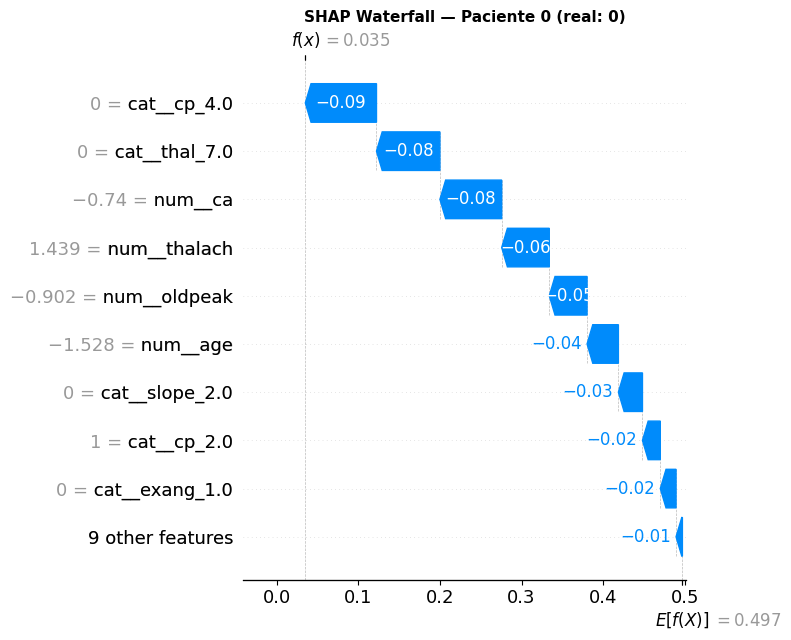

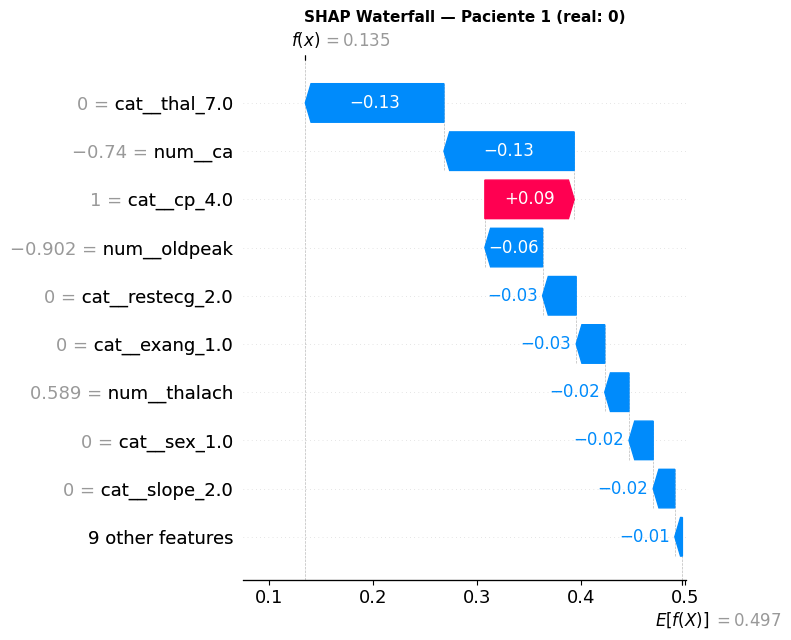

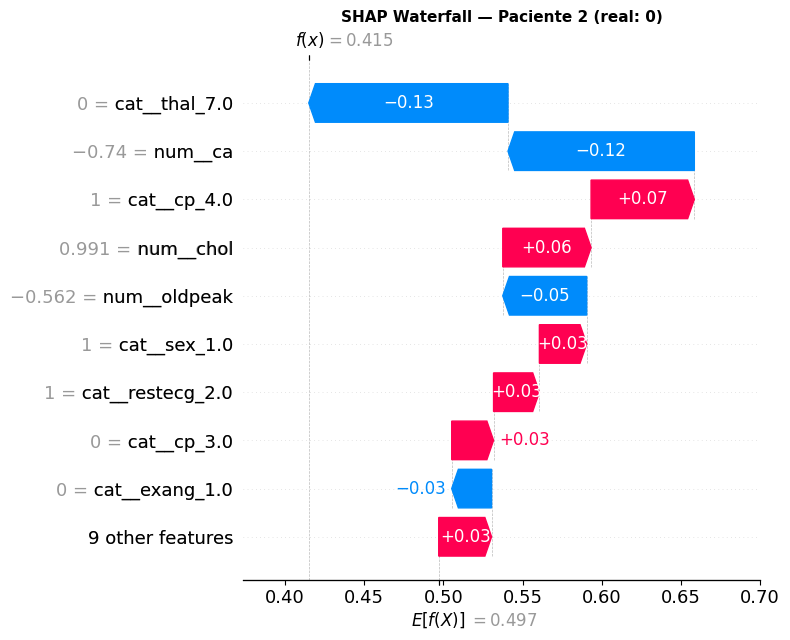

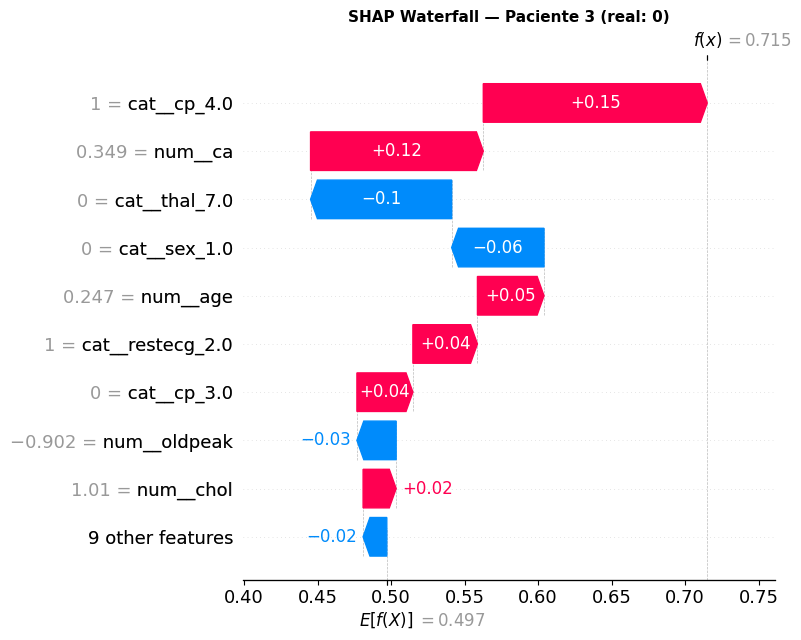

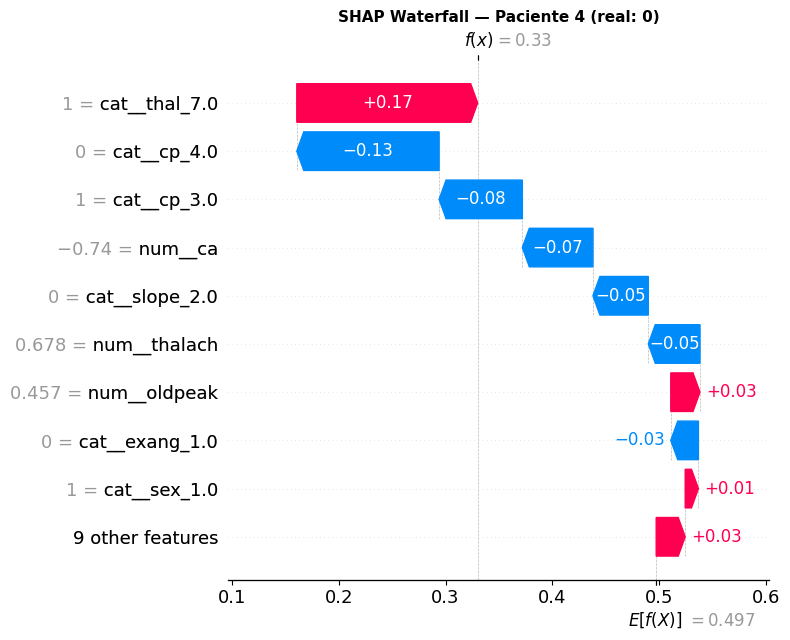

In [ ]:
#  Waterfall Plots — 5 pacientes

ev       = explainer_gs.expected_value
base_val = ev[1] if isinstance(ev, (list, np.ndarray)) else float(ev)

for sample_idx in range(5):
    expl = shap.Explanation(
        values        = shap_vals_gs[sample_idx],
        base_values   = base_val,
        data          = X_test_proc[sample_idx],
        feature_names = feature_names_shap
    )
    shap.waterfall_plot(expl, show=False)
    real_label = y_test.iloc[sample_idx]
    plt.title(f'SHAP Waterfall — Paciente {sample_idx} (real: {real_label})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'images/shap_gs_waterfall_{sample_idx}.png', dpi=300, bbox_inches='tight')
    plt.show()


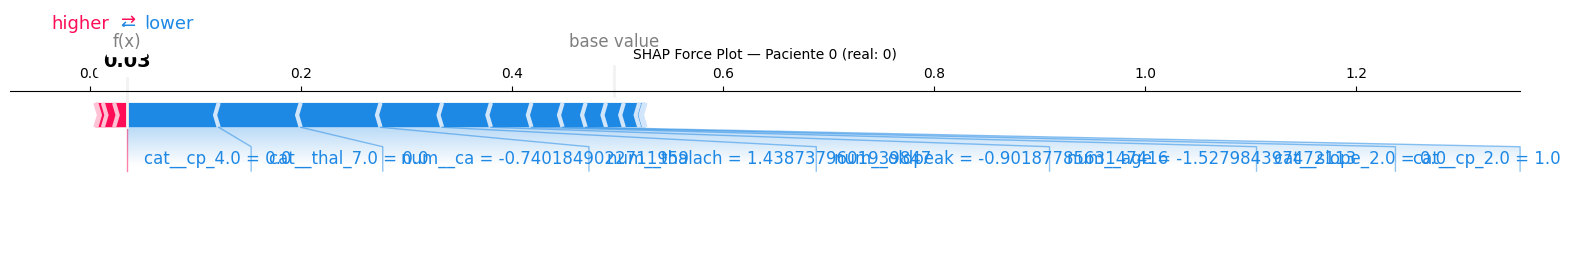

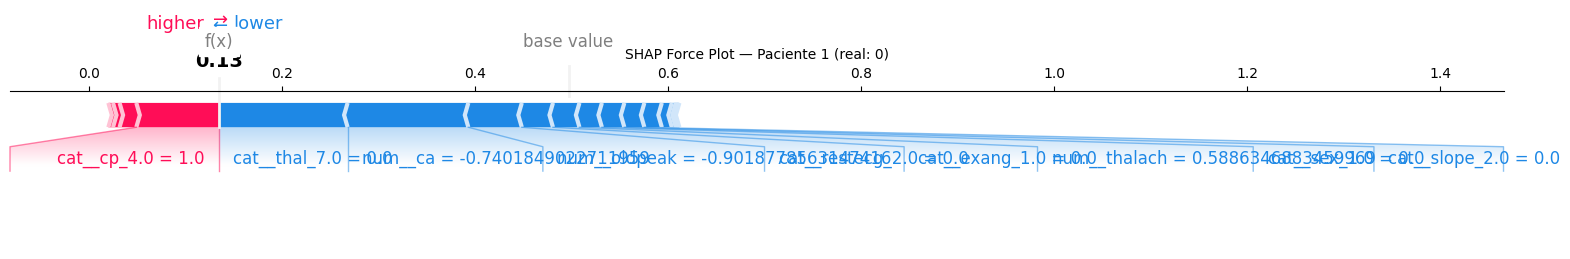

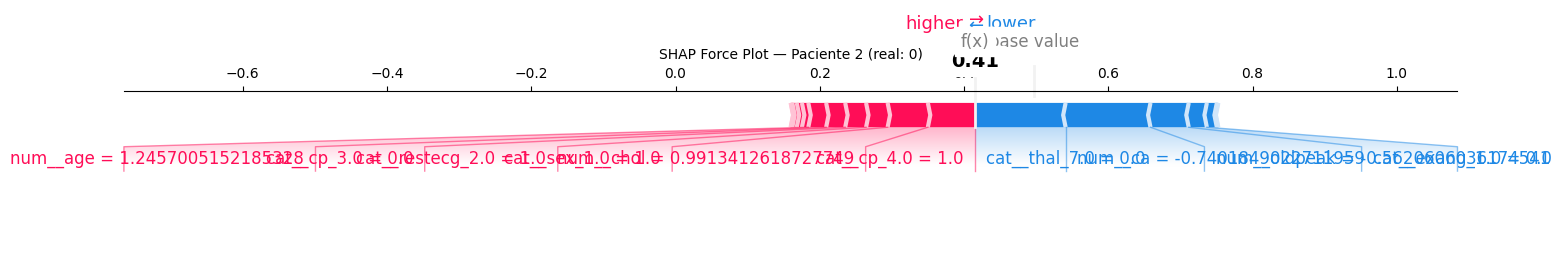

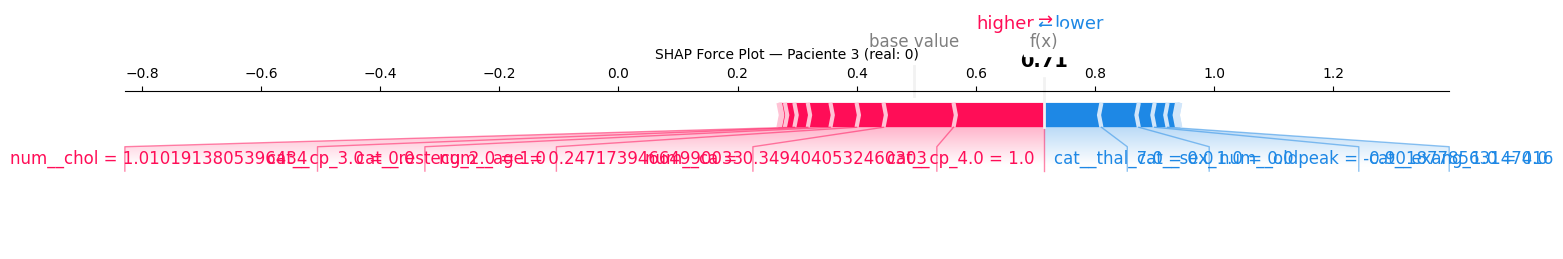

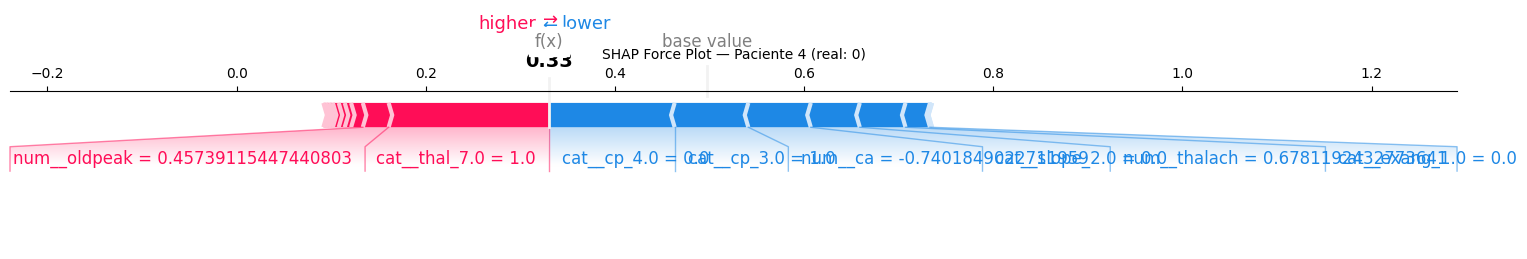

In [ ]:
#  Force Plots individuales — primeros 5 pacientes

ev       = explainer_gs.expected_value
base_val = ev[1] if isinstance(ev, (list, np.ndarray)) else float(ev)

for sample_idx in range(5):
    shap.force_plot(
        base_val,
        shap_vals_gs[sample_idx],
        X_test_proc[sample_idx],
        feature_names=feature_names_shap,
        show=False,
        matplotlib=True,
        figsize=(16, 3)
    )
    real_label = y_test.iloc[sample_idx]
    plt.title(f'SHAP Force Plot — Paciente {sample_idx} (real: {real_label})', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'images/shap_gs_force_{sample_idx}.png', dpi=200, bbox_inches='tight')
    plt.show()

## Curvas de Privacidad-Utilidad

Se simula el trade-off entre protección de datos y rendimiento predictivo añadiendo **ruido gaussiano diferencial** (mecanismo de Laplace escalado) con distintos valores de ε al conjunto de entrenamiento SMOTETomek. Un ε bajo implica más privacidad pero menor utilidad.

In [ ]:
# Simulación ruido diferencial

SEED = 42
np.random.seed(SEED)

sensitivity = float(np.max(np.linalg.norm(X_train_bal, axis=1)))
epsilons    = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, np.inf]
n_runs      = 10

priv_results = []
for eps in epsilons:
    aucs_run = []
    for _ in range(n_runs):
        if np.isinf(eps):
            X_noisy = X_train_bal.copy()
        else:
            sigma   = sensitivity / eps
            noise   = np.random.normal(0, sigma, X_train_bal.shape)
            X_noisy = X_train_bal + noise

        clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
        clf.fit(X_noisy, y_train_bal)
        yp = clf.predict_proba(X_test_proc)[:, 1]
        aucs_run.append(roc_auc_score(y_test, yp))

    priv_results.append({
        'epsilon' : eps,
        'auc_mean': np.mean(aucs_run),
        'auc_std' : np.std(aucs_run),
    })

df_priv = pd.DataFrame(priv_results)
print(df_priv.to_string(index=False))
df_priv.to_csv('tables/privacidad_utilidad.csv', index=False)


 epsilon  auc_mean      auc_std
    0.01  0.507589 7.745246e-03
    0.05  0.534208 1.195437e-01
    0.10  0.537388 1.917521e-01
    0.20  0.415737 2.157527e-01
    0.50  0.610658 1.716957e-01
    1.00  0.664509 1.506961e-01
    2.00  0.760212 1.194507e-01
    5.00  0.912835 3.317925e-02
   10.00  0.945647 1.328125e-02
   50.00  0.929408 7.116870e-03
     inf  0.921317 1.110223e-16


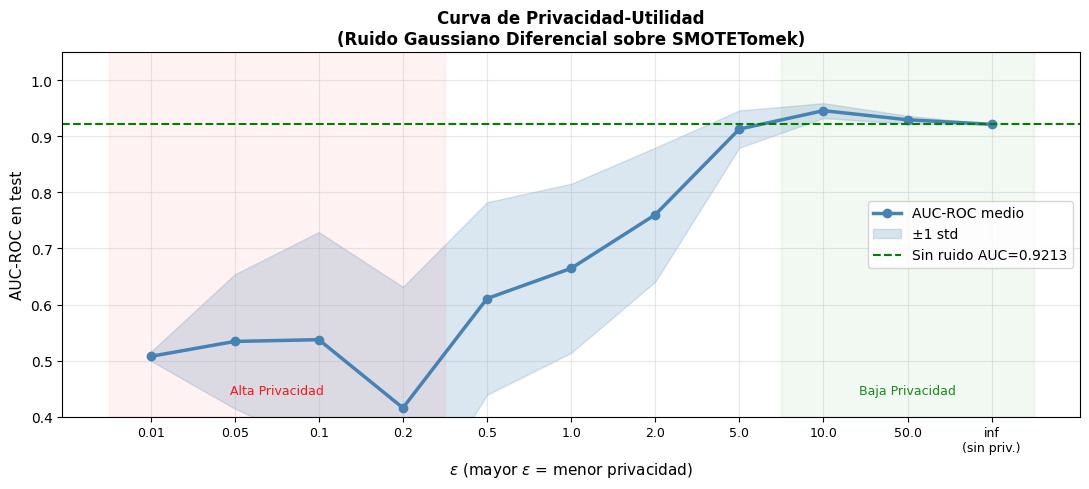

In [ ]:
# Plot: Curva Privacidad-Utilidad

eps_labels = [str(e) if not np.isinf(e) else 'inf\n(sin priv.)' for e in df_priv['epsilon']]
x_vals = np.arange(len(df_priv))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_vals, df_priv['auc_mean'], marker='o', lw=2.5, color='steelblue', label='AUC-ROC medio')
ax.fill_between(x_vals,
                df_priv['auc_mean'] - df_priv['auc_std'],
                df_priv['auc_mean'] + df_priv['auc_std'],
                alpha=0.2, color='steelblue', label='±1 std')
ax.axhline(df_priv['auc_mean'].iloc[-1], color='green', linestyle='--', lw=1.5,
           label=f"Sin ruido AUC={df_priv['auc_mean'].iloc[-1]:.4f}")

ax.set_xticks(x_vals)
ax.set_xticklabels(eps_labels, fontsize=9)
ax.set_xlabel(r'$\varepsilon$ (mayor $\varepsilon$ = menor privacidad)', fontsize=11)
ax.set_ylabel('AUC-ROC en test', fontsize=11)
ax.set_title('Curva de Privacidad-Utilidad\n(Ruido Gaussiano Diferencial sobre SMOTETomek)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0.4, 1.05)
ax.axvspan(-0.5, 3.5, alpha=0.05, color='red')
ax.text(1.5, 0.44, 'Alta Privacidad', ha='center', fontsize=9, color='red', alpha=0.9)
ax.axvspan(7.5, len(x_vals) - 0.5, alpha=0.05, color='green')
ax.text(9, 0.44, 'Baja Privacidad', ha='center', fontsize=9, color='green', alpha=0.9)

plt.tight_layout()
plt.savefig('images/curva_privacidad_utilidad.png', dpi=300, bbox_inches='tight')
plt.show()


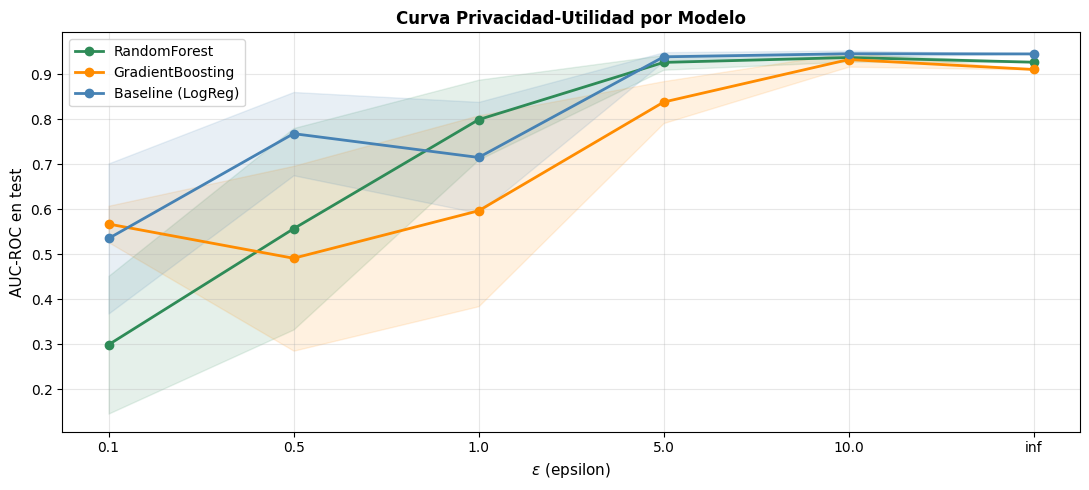

In [ ]:
#  Curvas privacidad-utilidad por modelo

from sklearn.linear_model import LogisticRegression as LR

models_priv = {
    'RandomForest'    : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                    max_depth=3, random_state=42),
    'Baseline (LogReg)': LR(C=1.0, max_iter=1000, random_state=42),
}
epsilons_short = [0.1, 0.5, 1.0, 5.0, 10.0, np.inf]
colors_priv    = {'RandomForest': 'seagreen', 'GradientBoosting': 'darkorange',
                  'Baseline (LogReg)': 'steelblue'}

fig, ax = plt.subplots(figsize=(11, 5))

for mname, mclf in models_priv.items():
    aucs_eps, stds_eps = [], []
    for eps in epsilons_short:
        aucs_run = []
        for _ in range(5):
            if np.isinf(eps):
                X_n = X_train_bal.copy()
            else:
                sigma = sensitivity / eps
                X_n   = X_train_bal + np.random.normal(0, sigma, X_train_bal.shape)
            mclf.fit(X_n, y_train_bal)
            yp = mclf.predict_proba(X_test_proc)[:, 1]
            aucs_run.append(roc_auc_score(y_test, yp))
        aucs_eps.append(np.mean(aucs_run))
        stds_eps.append(np.std(aucs_run))

    xv = np.arange(len(epsilons_short))
    ax.plot(xv, aucs_eps, marker='o', lw=2, label=mname, color=colors_priv[mname])
    ax.fill_between(xv,
                    np.array(aucs_eps) - np.array(stds_eps),
                    np.array(aucs_eps) + np.array(stds_eps),
                    alpha=0.12, color=colors_priv[mname])

ax.set_xticks(range(len(epsilons_short)))
ax.set_xticklabels([str(e) if not np.isinf(e) else 'inf' for e in epsilons_short], fontsize=10)
ax.set_xlabel(r'$\varepsilon$ (epsilon)', fontsize=11)
ax.set_ylabel('AUC-ROC en test', fontsize=11)
ax.set_title('Curva Privacidad-Utilidad por Modelo', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/curva_privacidad_por_modelo.png', dpi=300, bbox_inches='tight')
plt.show()


##  Análisis de Fairness — Métricas de Equidad

Se evalúa la equidad del modelo respecto al atributo sensible **sexo** (`sex`: 0=mujer, 1=hombre). Se calculan indicadores estándar: **Demographic Parity Difference**, **Equal Opportunity Difference**, **Equalized Odds** y **Disparate Impact Ratio**.

In [ ]:
#  Preparar grupos sensibles

sex_test = X_test['sex'].values   # 0=mujer, 1=hombre

# Predicciones mejor modelo GS
best_gs_model.fit(X_train_bal, y_train_bal)
y_prob_best = best_gs_model.predict_proba(X_test_proc)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

# Predicciones baseline
y_prob_base = baseline_model.predict_proba(X_test_proc)[:, 1]
y_pred_base = (y_prob_base >= 0.5).astype(int)

mask_f    = sex_test == 0
mask_m    = sex_test == 1
y_test_a  = y_test.values

print(f"Test — Mujeres: {mask_f.sum()} | Hombres: {mask_m.sum()}")
print(f"Prevalencia real — Mujeres: {y_test_a[mask_f].mean():.3f} | Hombres: {y_test_a[mask_m].mean():.3f}")


Test — Mujeres: 19 | Hombres: 41
Prevalencia real — Mujeres: 0.158 | Hombres: 0.610


In [ ]:
#  Función de métricas de fairness

def fairness_report(y_true, y_pred, y_prob, mask_0, mask_1,
                    gnames=('Mujeres', 'Hombres'), mname=''):
    res = {}
    for mask, gn in zip([mask_0, mask_1], gnames):
        yt, yp, ypr = y_true[mask], y_pred[mask], y_prob[mask]
        res[gn] = {
            'N'           : int(mask.sum()),
            'Prevalencia' : float(yt.mean()),
            'AUC-ROC'     : (roc_auc_score(yt, ypr)
                             if yt.sum() > 0 and (1-yt).sum() > 0 else float('nan')),
            'F1'          : float(f1_score(yt, yp, zero_division=0)),
            'Recall (TPR)': float(recall_score(yt, yp, zero_division=0)),
            'Precision'   : float(precision_score(yt, yp, zero_division=0)),
            'Accuracy'    : float(accuracy_score(yt, yp)),
            'FPR'         : float(((yp == 1) & (yt == 0)).sum() / max((yt == 0).sum(), 1)),
            'Pos Rate'    : float(yp.mean()),
        }

    df_r = pd.DataFrame(res).T
    g0, g1 = gnames
    dp  = abs(res[g0]['Pos Rate'] - res[g1]['Pos Rate'])
    eo  = abs(res[g0]['Recall (TPR)'] - res[g1]['Recall (TPR)'])
    fpr_diff = abs(res[g0]['FPR'] - res[g1]['FPR'])
    eqo = max(eo, fpr_diff)
    di  = (res[g0]['Pos Rate'] / res[g1]['Pos Rate']
           if res[g1]['Pos Rate'] > 0 else float('nan'))

    print(f"\n{'─'*55}")
    print(f"  Fairness — {mname}")
    print(f"{'─'*55}")
    cols_show = ['N','Prevalencia','AUC-ROC','F1','Recall (TPR)','FPR','Accuracy','Pos Rate']
    print(df_r[cols_show].to_string())
    print(f"\n  Demographic Parity Diff : {dp:.4f}  (ideal → 0)")
    print(f"  Equal Opportunity Diff  : {eo:.4f}  (ideal → 0)")
    print(f"  Equalized Odds Diff     : {eqo:.4f}  (ideal → 0)")
    print(f"  Disparate Impact Ratio  : {di:.4f}  (ideal → 1)")

    return df_r, {'DP': dp, 'EO': eo, 'EqO': eqo, 'DI': di}

df_fair_base, fi_base = fairness_report(y_test_a, y_pred_base, y_prob_base,
                                        mask_f, mask_m, mname='Baseline (LogReg)')
df_fair_best, fi_best = fairness_report(y_test_a, y_pred_best, y_prob_best,
                                        mask_f, mask_m, mname=best_gs_name)



───────────────────────────────────────────────────────
  Fairness — Baseline (LogReg)
───────────────────────────────────────────────────────
            N  Prevalencia  AUC-ROC        F1  Recall (TPR)     FPR  Accuracy  Pos Rate
Mujeres  19.0     0.157895   1.0000  0.800000      0.666667  0.0000  0.947368  0.105263
Hombres  41.0     0.609756   0.9075  0.857143      0.840000  0.1875  0.829268  0.585366

  Demographic Parity Diff : 0.4801  (ideal → 0)
  Equal Opportunity Diff  : 0.1733  (ideal → 0)
  Equalized Odds Diff     : 0.1875  (ideal → 0)
  Disparate Impact Ratio  : 0.1798  (ideal → 1)

───────────────────────────────────────────────────────
  Fairness — SVM_rbf
───────────────────────────────────────────────────────
            N  Prevalencia  AUC-ROC        F1  Recall (TPR)     FPR  Accuracy  Pos Rate
Mujeres  19.0     0.157895    1.000  1.000000          1.00  0.0000  1.000000  0.157895
Hombres  41.0     0.609756    0.935  0.857143          0.84  0.1875  0.829268  0.585366



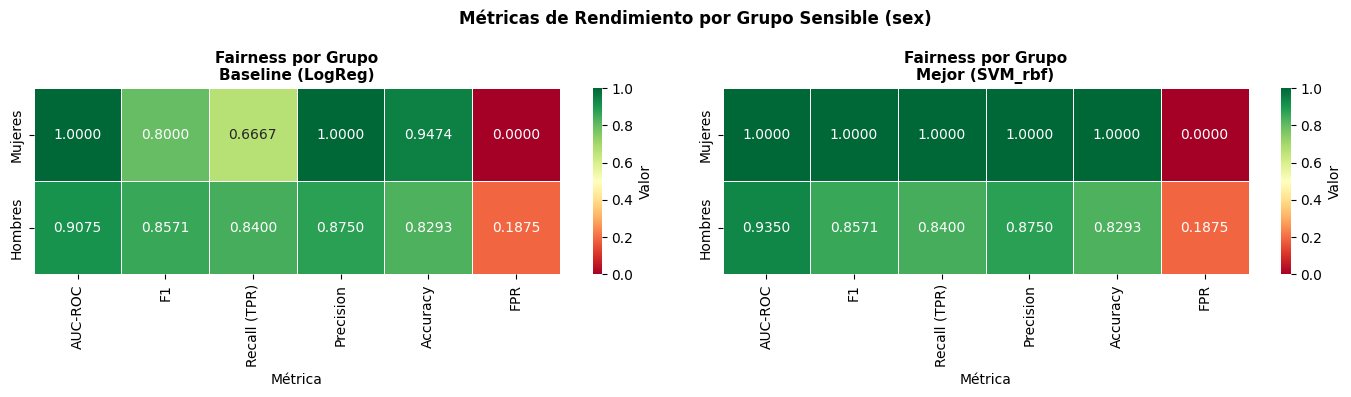

In [ ]:
# Heatmap métricas por grupo

mcols = ['AUC-ROC', 'F1', 'Recall (TPR)', 'Precision', 'Accuracy', 'FPR']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df_f, title) in zip(axes, [
    (df_fair_base[mcols].astype(float), 'Baseline (LogReg)'),
    (df_fair_best[mcols].astype(float), f'Mejor ({best_gs_name})')
]):
    sns.heatmap(df_f, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Valor'})
    ax.set_title(f'Fairness por Grupo\n{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Métrica')

plt.suptitle('Métricas de Rendimiento por Grupo Sensible (sex)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fairness_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


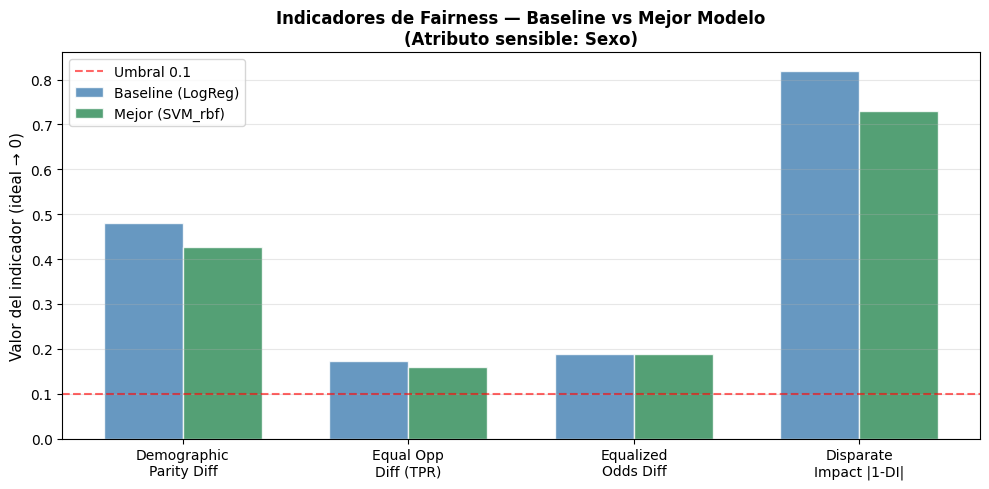

In [ ]:
# Indicadores de fairness

fair_ind = {
    'Demographic\nParity Diff'  : (fi_base['DP'],          fi_best['DP']),
    'Equal Opp\nDiff (TPR)'     : (fi_base['EO'],          fi_best['EO']),
    'Equalized\nOdds Diff'      : (fi_base['EqO'],         fi_best['EqO']),
    'Disparate\nImpact |1-DI|'  : (abs(1 - fi_base['DI']), abs(1 - fi_best['DI'])),
}

x_fi   = np.arange(len(fair_ind))
w_fi   = 0.35
lbl_fi = list(fair_ind.keys())
v_base = [v[0] for v in fair_ind.values()]
v_best = [v[1] for v in fair_ind.values()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_fi - w_fi/2, v_base, w_fi, label='Baseline (LogReg)',
       color='steelblue', alpha=0.82, edgecolor='white')
ax.bar(x_fi + w_fi/2, v_best, w_fi, label=f'Mejor ({best_gs_name})',
       color='seagreen', alpha=0.82, edgecolor='white')
ax.axhline(0.1, color='red', linestyle='--', lw=1.5, alpha=0.6, label='Umbral 0.1')
ax.set_xticks(x_fi)
ax.set_xticklabels(lbl_fi, fontsize=10)
ax.set_ylabel('Valor del indicador (ideal → 0)', fontsize=11)
ax.set_title('Indicadores de Fairness — Baseline vs Mejor Modelo\n(Atributo sensible: Sexo)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/fairness_indicators.png', dpi=300, bbox_inches='tight')
plt.show()


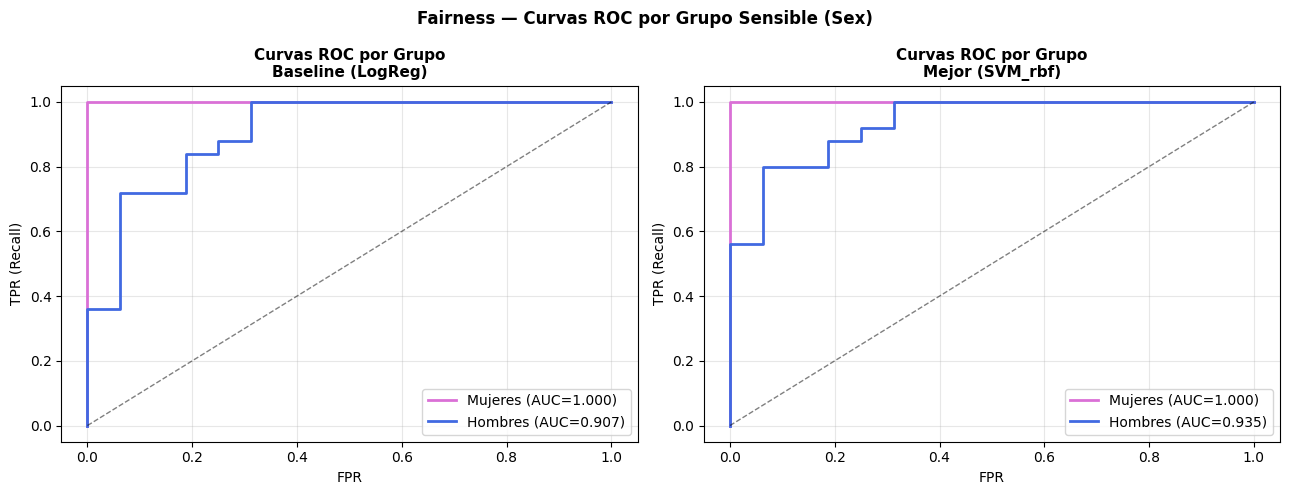

In [ ]:
#  Curvas ROC por grupo

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
g_masks  = {'Mujeres': mask_f, 'Hombres': mask_m}
g_colors = {'Mujeres': 'orchid', 'Hombres': 'royalblue'}

for ax, (mname, yp) in zip(axes, [
    ('Baseline (LogReg)', y_prob_base),
    (f'Mejor ({best_gs_name})', y_prob_best)
]):
    for gn, mask in g_masks.items():
        fpr_g, tpr_g, _ = roc_curve(y_test_a[mask], yp[mask])
        auc_g = roc_auc_score(y_test_a[mask], yp[mask])
        ax.plot(fpr_g, tpr_g, lw=2, color=g_colors[gn],
                label=f'{gn} (AUC={auc_g:.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR (Recall)')
    ax.set_title(f'Curvas ROC por Grupo\n{mname}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Fairness — Curvas ROC por Grupo Sensible (Sex)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/fairness_roc_por_grupo.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Tabla resumen global fairness + rendimiento

summary_rows = []
for mname2, y_pred_m, y_prob_m in [
    ('Baseline (LogReg)',            y_pred_base, y_prob_base),
    (f'{best_gs_name} (mejor GS)',   y_pred_best, y_prob_best)
]:
    row = {
        'Modelo'         : mname2,
        'AUC-ROC Global' : f"{roc_auc_score(y_test_a, y_prob_m):.4f}",
        'F1 Global'      : f"{f1_score(y_test_a, y_pred_m):.4f}",
        'Recall Global'  : f"{recall_score(y_test_a, y_pred_m):.4f}",
    }
    for gn, mask in g_masks.items():
        row[f'AUC {gn}'] = f"{roc_auc_score(y_test_a[mask], y_prob_m[mask]):.4f}"
        row[f'F1 {gn}']  = f"{f1_score(y_test_a[mask], y_pred_m[mask], zero_division=0):.4f}"
    summary_rows.append(row)

df_sf = pd.DataFrame(summary_rows).set_index('Modelo')
print("\nResumen Final: Rendimiento + Fairness")
print(df_sf.to_string())
df_sf.to_csv('tables/resumen_fairness.csv')



Resumen Final: Rendimiento + Fairness
                   AUC-ROC Global F1 Global Recall Global AUC Mujeres F1 Mujeres AUC Hombres F1 Hombres
Modelo                                                                                                 
Baseline (LogReg)          0.9498    0.8519        0.8214      1.0000     0.8000      0.9075     0.8571
SVM_rbf (mejor GS)         0.9609    0.8727        0.8571      1.0000     1.0000      0.9350     0.8571
